In [3]:
df_dni=df_vici.toPandas()
ruta_archivo = os.path.join(ruta_csv, 'solo_10777139_dinersTC.xlsx')

df_dni.to_excel(ruta_archivo, index=False)

In [1]:
import sys 
sys.path.append('C:/Users/DATA/Documents/datos/01_script/inicio/funciones')
from funciones import *
from funciones_spark import *
from variables_inicio import *
from utils_sql import *

spark = SparkSession.builder \
    .appName("SparkExample") \
    .master("local[*]") \
    .config('spark.driver.extraClassPath', 'C:/spark/jars/mssql-jdbc-13.2.1.jre11.jar') \
    .config('spark.executor.extraClassPath', 'C:/spark/jars/mssql-jdbc-13.2.1.jre11.jar') \
    .config('spark.executor.memory', '5g') \
    .config('spark.driver.memory', '5g') \
    .getOrCreate()

In [8]:
dni=['41253846',
'22297977',
'42078924',
'73217371',
'47192090',
'46201649',
'72573360',
'47048010',
'40160218',
'71086091',
'45463535',
'45306607',
'71590140',
'72683046',
'74207064',
'74471251',
'70275812',
'71701700',
'40192055',
'73123057',
'07755172',
'72934125',
'48363586'
]

In [12]:
df=df_vici.filter(
    (F.col('fecha_hora_llamada')>='2026-07-01')&
    (F.col('vendor_lead_code').isin(dni))
)

In [13]:
window_spec = Window.partitionBy("vendor_lead_code").orderBy(F.col("peso").asc_nulls_last(),F.col("fecha_hora_llamada").desc_nulls_last())
df = df.withColumn("ref1_vici", row_number().over(window_spec))
df = df.filter(F.col('ref1_vici')==1).drop('ref1_vici','peso')    

In [14]:
df.count()

23

In [16]:
df_a=since_base_maestra_tc_dinners(spark)

In [17]:
df=df.join(df_a,['vendor_lead_code'],'left')

In [4]:
df_list_filtrada = df_list_1.toPandas()
ruta_archivo = os.path.join(ruta_csv, 'rg.xlsx')
df_list_filtrada.to_excel(ruta_archivo, index=False)

In [6]:
df_vici.filter(F.col('vendor_lead_code').isin(dni)).orderBy(F.col('fecha_hora_llamada').desc()).show(truncate=False)


+-------------------+-----------+----------------+------------+-------------------------------------+-------------+------------------------------------+-----------------------+------------+--------+----------------------------+--------+------+-----------------+
|fecha_hora_llamada |list_name  |vendor_lead_code|phone_number|descripcion                          |dni_ejecutivo|ejecutivo                           |dial_method            |term_reason |alt_dial|call_result                 |duracion|codigo|nombre_campana   |
+-------------------+-----------+----------------+------------+-------------------------------------+-------------+------------------------------------+-----------------------+------------+--------+----------------------------+--------+------+-----------------+
|2026-07-20 17:29:03|CET_CD     |22297977        |994006712   |TELEFONO APAGADO                     |VDAD         |Outbound Auto Dial                  |RATIO                  |NONE        |NONE    |Busy Auto       

In [ ]:
df_vici.filter(F.col('fecha_hora_llamada')>='2026-07-01').orderBy(F.col('fecha_hora_llamada').desc()).show(truncate=False)


In [5]:
df_vici=df_vici.dropDuplicates(['vendor_lead_code'])

In [2]:
        
query=f'''
    select distinct vendor_lead_code,mejor_descripcion_cli from cronox.dbo.borrar_tc_dinner
    where fecha_envio>='2026-07-06'
'''
df_list = obtener_tabla_sql(spark,query,server_sa,user_sa,pwd_sa,db_sa)
df_list=df_list.filter(F.col('mejor_descripcion_cli').isin(mejor_descripcion_cli)).drop('mejor_descripcion_cli')
df_vici=df_vici.join(df_list,['vendor_lead_code'],'inner')


NameError: name 'mejor_descripcion_cli' is not defined

In [57]:
df_vici=df_vici.filter(F.col('fecha_hora_llamada')>='2026-06-11')

df_vici = df_vici.withColumn(
    "contacto_efectivo",
    F.when(F.col("descripcion").isin('CONTACTO EFECTIVO'), 1).otherwise(0)
)

df_vici = (
    df_vici
    .withColumn("hora", F.hour("fecha_hora_llamada"))
    .withColumn(
        "franja",
        F.format_string(
            "%02d:00-%02d:00",
            F.hour("fecha_hora_llamada"),
            F.hour("fecha_hora_llamada") + 1
        )
    )
)
df_resumen = (
    df_vici
    .groupBy("vendor_lead_code", "franja")
    .agg(
        F.count("*").alias("intentos"),
        F.sum("contacto_efectivo").alias("contactos")
    )
    .withColumn(
        "pct_contactabilidad",
        F.round(F.col("contactos") / F.col("intentos"), 4)
    )
)
min_intentos = 3

w = Window.partitionBy("vendor_lead_code").orderBy(
    F.col("pct_contactabilidad").desc(),
    F.col("intentos").desc()
)

df_mejor_hora = (
    df_resumen
    .filter(F.col("intentos") >= min_intentos)
    .withColumn("rn", F.row_number().over(w))
    .filter(F.col("rn") == 1)
    .select(
        "vendor_lead_code",
        F.col("franja").alias("mejor_hora"),
        F.col("pct_contactabilidad").alias("pct_mejor_hora"),
        F.col("intentos").alias("intentos_mejor_hora")
    )
)

In [58]:
df_bttc_final =df_resumen.join(df_mejor_hora, ['vendor_lead_code'],"left")
df_bttc_final.show()

+----------------+-----------+--------+---------+-------------------+-----------+--------------+-------------------+
|vendor_lead_code|     franja|intentos|contactos|pct_contactabilidad| mejor_hora|pct_mejor_hora|intentos_mejor_hora|
+----------------+-----------+--------+---------+-------------------+-----------+--------------+-------------------+
|        07733411|13:00-14:00|       5|        0|                0.0|13:00-14:00|           0.0|                  5|
|        07733411|16:00-17:00|       3|        0|                0.0|13:00-14:00|           0.0|                  5|
|        10137411|16:00-17:00|       4|        0|                0.0|16:00-17:00|           0.0|                  4|
|        29721441|10:00-11:00|       1|        0|                0.0|       NULL|          NULL|               NULL|
|        41210321|13:00-14:00|       2|        0|                0.0|       NULL|          NULL|               NULL|
|        41210321|09:00-10:00|       2|        0|               

In [59]:
df_intentos = (
    df_resumen
    .groupBy("vendor_lead_code")
    .pivot("franja")
    .agg(F.first("intentos"))
)

for col in df_intentos.columns:
    if col != "vendor_lead_code":
        df_intentos = df_intentos.withColumnRenamed(
            col,
            f"Intentos {col}"
        )
        
df_pct = (
    df_resumen
    .groupBy("vendor_lead_code")
    .pivot("franja")
    .agg(F.first("pct_contactabilidad"))
)

for col in df_pct.columns:
    if col != "vendor_lead_code":
        df_pct = df_pct.withColumnRenamed(
            col,
            f"% Contacto {col}"
        )
        
df_bttc_ancho = (
    df_intentos
    .join(df_pct, on="vendor_lead_code", how="left")
    .join(df_mejor_hora, on="vendor_lead_code", how="left")
)

In [60]:
# df_bttc_ancho.show(20, False)

In [61]:
df_bttc_final_1=df_bttc_final.filter(F.col('mejor_hora').isNotNull())

In [63]:
df_bttc_final_1.groupBy('mejor_hora') \
    .count() \
    .orderBy('mejor_hora') \
    .show(30)


+-----------+-----+
| mejor_hora|count|
+-----------+-----+
|09:00-10:00| 4661|
|10:00-11:00|10341|
|11:00-12:00|16377|
|12:00-13:00| 5804|
|13:00-14:00|11009|
|14:00-15:00|   36|
|15:00-16:00| 3323|
|16:00-17:00| 8389|
|17:00-18:00| 3107|
|18:00-19:00|  150|
+-----------+-----+



In [23]:
print(df_bttc_final.columns)

['vendor_lead_code', 'franja', 'intentos', 'contactos', 'pct_contactabilidad', 'mejor_hora', 'pct_mejor_hora', 'intentos_mejor_hora']


In [19]:
df_resumen.show(10)

+----------------+-----------+--------+---------+-------------------+
|vendor_lead_code|     franja|intentos|contactos|pct_contactabilidad|
+----------------+-----------+--------+---------+-------------------+
|        44075411|12:00-13:00|       1|        0|                0.0|
|        75921795|12:00-13:00|       2|        0|                0.0|
|        40497490|16:00-17:00|       1|        0|                0.0|
|        70883591|16:00-17:00|       1|        0|                0.0|
|        44892879|18:00-19:00|       1|        0|                0.0|
|        40044203|11:00-12:00|       3|        0|                0.0|
|        72688918|13:00-14:00|       2|        0|                0.0|
|        46128856|09:00-10:00|       2|        0|                0.0|
|        73644772|13:00-14:00|       2|        0|                0.0|
|        75171353|16:00-17:00|       1|        0|                0.0|
+----------------+-----------+--------+---------+-------------------+
only showing top 10 

In [ ]:
df_bttc_final_1.groupBy('mejor_hora') \
    .count() \
    .orderBy('mejor_hora') \
    .show(30)

In [65]:
print(df_bttc_final_1.columns)


['vendor_lead_code', 'franja', 'intentos', 'contactos', 'pct_contactabilidad', 'mejor_hora', 'pct_mejor_hora', 'intentos_mejor_hora']


In [2]:
        
query=f'''
    select  * from cronox.dbo.borrar_tc_dinner
    where vendor_lead_code='48255478'
'''
df_list_1 = obtener_tabla_sql(spark,query,server_sa,user_sa,pwd_sa,db_sa)

# print(df_list.columns)


In [3]:
df_list_1.show()

+----------------+------------+------+----------+---------+-----------+--------+--------------------+----+--------+--------------------+----------------+--------+-----------------+--------------+----------------+----------+----------+---------------+------+------+-----+--------------+-------------+-----+------+-----+-----+-----+------+-----+-----+-----+--------+-----+-----+-----+-----+-----+-----+-----+--------+----------+---------+------+--------+---------+----+------+------+--------+--------+--------+--------------+-----+------+------------+-----------+---------+-------------+---------+-------------+-----------+----------+----+---------------+--------------------+-----+----------------+----+--------------------+-------------+-------------------+----------+---------------+--------------+---------+---------------------+---------------------+---------------------+--------------+-------------------+-------------------+-----------------------+------------+----------------------+----------

In [67]:
df_bttc_final_2=df_bttc_final_1.join(df_list_1,['vendor_lead_code'],'inner')

In [68]:
df_bttc_final_2.groupBy('mejor_hora','prob_contacto') \
    .count() \
    .orderBy('mejor_hora') \
    .show(30)

+-----------+-------------+-----+
| mejor_hora|prob_contacto|count|
+-----------+-------------+-----+
|09:00-10:00|     6. PLATA| 3032|
|09:00-10:00|       5. ORO|  406|
|09:00-10:00|      4. RUBI|  142|
|09:00-10:00|  1. DIAMANTE|   30|
|09:00-10:00| 3. ESMERALDA|  349|
|09:00-10:00|    7. BRONCE|  510|
|09:00-10:00|    2. ZAFIRO|  192|
|10:00-11:00|       5. ORO|  123|
|10:00-11:00|    7. BRONCE|  191|
|10:00-11:00|    2. ZAFIRO|   44|
|10:00-11:00|  1. DIAMANTE|   21|
|10:00-11:00|     6. PLATA| 9293|
|10:00-11:00| 3. ESMERALDA|  154|
|10:00-11:00|      4. RUBI|  515|
|11:00-12:00|     6. PLATA|13709|
|11:00-12:00|       5. ORO|  349|
|11:00-12:00| 3. ESMERALDA|  484|
|11:00-12:00|    7. BRONCE|  311|
|11:00-12:00|  1. DIAMANTE|   55|
|11:00-12:00|    2. ZAFIRO|  440|
|11:00-12:00|      4. RUBI| 1029|
|12:00-13:00|     6. PLATA| 2988|
|12:00-13:00|  1. DIAMANTE|  119|
|12:00-13:00|       5. ORO|  621|
|12:00-13:00|    2. ZAFIRO|  461|
|12:00-13:00|    7. BRONCE|  574|
|12:00-13:00| 

In [69]:

df_pivot = (
    df_bttc_final_2
    .groupBy("mejor_hora")
    .pivot("prob_contacto")
    .count()
    .fillna(0)
)

df_pivot.show()
# print(df_filtrado.count(),'leads')


+-----------+-----------+---------+------------+-------+------+--------+---------+
| mejor_hora|1. DIAMANTE|2. ZAFIRO|3. ESMERALDA|4. RUBI|5. ORO|6. PLATA|7. BRONCE|
+-----------+-----------+---------+------------+-------+------+--------+---------+
|17:00-18:00|         14|       60|         442|    211|   187|    2043|      150|
|13:00-14:00|        450|     2822|         253|   1074|   495|    4018|     1897|
|11:00-12:00|         55|      440|         484|   1029|   349|   13709|      311|
|15:00-16:00|          0|      128|        1488|    429|    48|     475|      755|
|12:00-13:00|        119|      461|          46|    995|   621|    2988|      574|
|18:00-19:00|          0|        0|           0|      2|     4|     119|       25|
|10:00-11:00|         21|       44|         154|    515|   123|    9293|      191|
|16:00-17:00|        102|      821|        4155|    377|   145|    2100|      689|
|09:00-10:00|         30|      192|         349|    142|   406|    3032|      510|
|14:

In [20]:
import sys 
sys.path.append('C:/Users/DATA/Documents/datos/01_script/inicio/funciones')
from funciones import *
from funciones_spark import *
from variables_inicio import *
from utils_sql import *

spark = SparkSession.builder \
    .appName("SparkExample") \
    .master("local[*]") \
    .config('spark.driver.extraClassPath', 'C:/spark/jars/mssql-jdbc-13.2.1.jre11.jar') \
    .config('spark.executor.extraClassPath', 'C:/spark/jars/mssql-jdbc-13.2.1.jre11.jar') \
    .config('spark.executor.memory', '5g') \
    .config('spark.driver.memory', '5g') \
    .getOrCreate()

In [10]:
query = f"""
select * from SAMANTHA.dbo.Historial_Target_Diners_TC 
where convert(date,FECHA_INICIO_GESTION)>='2026-07-01'
    """
df_feedback=obtener_tabla_sql(spark,query,server_zeus,user_zeus,pwd_zeus,db_zeus)

df_feedback_pd=df_feedback.toPandas()
df_feedback_pd['FECHA_INICIO_GESTION_ref'] = pd.to_datetime(
    df_feedback_pd['FECHA_INICIO_GESTION']
)

df_feedback_pd['fecha_archivo'] = (
    df_feedback_pd['FECHA_INICIO_GESTION_ref'].dt.date
)

for fecha, df_dia in df_feedback_pd.groupby('fecha_archivo'):

    nombre_fecha = fecha.strftime('%d_%m_%Y')
    nombre_archivo = f'FEEDBACK_TARGET_TC_{nombre_fecha}.xlsx'
    ruta_archivo = os.path.join(ruta_csv, nombre_archivo)
    df_exportar = df_dia.drop(
        columns=[
            'FECHA_INICIO_GESTION_ref',
            'fecha_archivo'
        ]
    )
    df_exportar.to_excel(
        ruta_archivo,
        index=False
    )
    print(f'Archivo generado: {ruta_archivo} | filas: {len(df_exportar)}')

Archivo generado: C:\Users\DATA\Documents\datos\05_subir_csv\FEEDBACK_TARGET_TC_01_07_2026.xlsx | filas: 19914
Archivo generado: C:\Users\DATA\Documents\datos\05_subir_csv\FEEDBACK_TARGET_TC_02_07_2026.xlsx | filas: 24815
Archivo generado: C:\Users\DATA\Documents\datos\05_subir_csv\FEEDBACK_TARGET_TC_03_07_2026.xlsx | filas: 23660
Archivo generado: C:\Users\DATA\Documents\datos\05_subir_csv\FEEDBACK_TARGET_TC_04_07_2026.xlsx | filas: 10838
Archivo generado: C:\Users\DATA\Documents\datos\05_subir_csv\FEEDBACK_TARGET_TC_06_07_2026.xlsx | filas: 27815
Archivo generado: C:\Users\DATA\Documents\datos\05_subir_csv\FEEDBACK_TARGET_TC_07_07_2026.xlsx | filas: 23427
Archivo generado: C:\Users\DATA\Documents\datos\05_subir_csv\FEEDBACK_TARGET_TC_08_07_2026.xlsx | filas: 18398
Archivo generado: C:\Users\DATA\Documents\datos\05_subir_csv\FEEDBACK_TARGET_TC_09_07_2026.xlsx | filas: 17365
Archivo generado: C:\Users\DATA\Documents\datos\05_subir_csv\FEEDBACK_TARGET_TC_10_07_2026.xlsx | filas: 9001
Ar

In [35]:
df_feedback_pd.head()

,DNI,TELEFONO,ID,CLASIFICACION,CALL,NUMERO_GESTIONES_REALIZADAS,FECHA_INICIO_GESTION,FECHA_FIN_LLAMADA,FECHA_HORA_MEJOR_GESTION,DURACION_LLAMADA_EFECTIVA,DURACION_LLAMADA_NO_EFECTIVA,EJECUTIVO,DNI_EJECUTIVO,OBSERVCION_GESTION,MONTO_VENDIDO,TIPO_BD,FECHA_INICIO_GESTION_ref,fecha_archivo
0,07760019,990353441,33,CONTACTO EFECTIVO>>LLAMADA INCONCLUSA>>SOCIO C...,TARGET,1,2026-07-06 11:29:59,2026-07-06 11:31:17,2026-07-06 11:29:59,01 minuto(s) 18 segundo(s),None,OSCAR EDUARDO MARCAS PINTADO,72800421,None,None,PPD,2026-07-06 11:29:59,2026-07-06
1,07760077,992730497,39,NO CONTACTO>>NO CONTACTO>>NO CONTESTA,TARGET,1,2026-07-06 12:05:17,2026-07-06 12:05:17,2026-07-06 12:05:17,None,00 minuto(s) 00 segundo(s),MARCADOR,MARCADOR,None,None,PPD,2026-07-06 12:05:17,2026-07-06
2,07760176,997919693,39,NO CONTACTO>>NO CONTACTO>>NO CONTESTA,TARGET,1,2026-07-06 09:17:02,2026-07-06 09:17:02,2026-07-06 09:17:02,None,00 minuto(s) 00 segundo(s),MARCADOR,MARCADOR,None,None,PPD,2026-07-06 09:17:02,2026-07-06
3,07761071,998495653,39,NO CONTACTO>>NO CONTACTO>>NO CONTESTA,TARGET,1,2026-07-06 12:56:43,2026-07-06 12:56:43,2026-07-06 12:56:43,None,00 minuto(s) 00 segundo(s),MARCADOR,MARCADOR,None,None,PPD,2026-07-06 12:56:43,2026-07-06
4,07765774,952002212,34,TELEFONO/LINEA OPERATIVA>>TELEFONO/LINEA OPERA...,TARGET,1,2026-07-06 13:01:44,2026-07-06 13:01:44,2026-07-06 13:01:44,None,None,MARCADOR,MARCADOR,None,None,PPD,2026-07-06 13:01:44,2026-07-06


In [ ]:
display(
    df_feedback_pd.groupby(['DNI', 'DETALLE_TASA'])
    .size()
    .reset_index(name='count')
    .sort_values(['DNI', 'DETALLE_TASA'])
)

In [ ]:
# append_table_SQL(spark,df_bttc_final_2,f'lista_dni_fecha_tc_diners',server_kishin,user_kishin,pwd_kishin,'DANTALION')
# append_table_SQL(spark,df_bttc_final_2,f'lista_dni_fecha_tc_diners',server_sa,user_sa,pwd_sa,'cronox')



In [15]:
query = f"""
select * from SAMANTHA.dbo.Historial_Target_Diners_TC 
where convert(date,FECHA_INICIO_GESTION)>='2026-07-01'
    """
df_feedback=obtener_tabla_sql(spark,query,server_zeus,user_zeus,pwd_zeus,db_zeus)

df_feedback_pd=df_feedback.toPandas()
df_feedback_pd['FECHA_INICIO_GESTION_ref'] = pd.to_datetime(
    df_feedback_pd['FECHA_INICIO_GESTION']
)

df_feedback_pd['fecha_archivo'] = (
    df_feedback_pd['FECHA_INICIO_GESTION_ref'].dt.date
)

for fecha, df_dia in df_feedback_pd.groupby('fecha_archivo'):

    nombre_fecha = fecha.strftime('%d_%m_%Y')
    nombre_archivo = f'FEEDBACK_TARGET_TC_{nombre_fecha}.xlsx'
    ruta_archivo = os.path.join(ruta_csv, nombre_archivo)
    df_exportar = df_dia.drop(
        columns=[
            'FECHA_INICIO_GESTION_ref',
            'fecha_archivo'
        ]
    )
    df_exportar.to_excel(
        ruta_archivo,
        index=False
    )
    print(f'Archivo generado: {ruta_archivo} | filas: {len(df_exportar)}')

Archivo generado: C:\Users\DATA\Documents\datos\05_subir_csv\FEEDBACK_TARGET_TC_01_07_2026.xlsx | filas: 19727
Archivo generado: C:\Users\DATA\Documents\datos\05_subir_csv\FEEDBACK_TARGET_TC_02_07_2026.xlsx | filas: 24600
Archivo generado: C:\Users\DATA\Documents\datos\05_subir_csv\FEEDBACK_TARGET_TC_03_07_2026.xlsx | filas: 23484
Archivo generado: C:\Users\DATA\Documents\datos\05_subir_csv\FEEDBACK_TARGET_TC_04_07_2026.xlsx | filas: 10770
Archivo generado: C:\Users\DATA\Documents\datos\05_subir_csv\FEEDBACK_TARGET_TC_06_07_2026.xlsx | filas: 27815
Archivo generado: C:\Users\DATA\Documents\datos\05_subir_csv\FEEDBACK_TARGET_TC_07_07_2026.xlsx | filas: 23427
Archivo generado: C:\Users\DATA\Documents\datos\05_subir_csv\FEEDBACK_TARGET_TC_08_07_2026.xlsx | filas: 18398
Archivo generado: C:\Users\DATA\Documents\datos\05_subir_csv\FEEDBACK_TARGET_TC_09_07_2026.xlsx | filas: 25847
Archivo generado: C:\Users\DATA\Documents\datos\05_subir_csv\FEEDBACK_TARGET_TC_10_07_2026.xlsx | filas: 28423
A

In [16]:
df_feedback.select('DNI').distinct().count()


15265

In [27]:
query = f"""
select * from SAMANTHA.dbo.Historial_Target_Diners_PPD 
where convert(date,FECHA_INICIO_GESTION)>='2026-07-01'
    """
df_feedback=obtener_tabla_sql(spark,query,server_zeus,user_zeus,pwd_zeus,db_zeus)
df_feedback_pd=df_feedback.toPandas()
df_feedback_pd['FECHA_INICIO_GESTION_ref'] = pd.to_datetime(
    df_feedback_pd['FECHA_INICIO_GESTION']
)

df_feedback_pd['fecha_archivo'] = (
    df_feedback_pd['FECHA_INICIO_GESTION_ref'].dt.date
)

for fecha, df_dia in df_feedback_pd.groupby('fecha_archivo'):

    nombre_fecha = fecha.strftime('%d_%m_%Y')
    nombre_archivo = f'FEEDBACK_TARGET_PPD_{nombre_fecha}.xlsx'
    ruta_archivo = os.path.join(ruta_csv, nombre_archivo)
    df_exportar = df_dia.drop(
        columns=[
            'FECHA_INICIO_GESTION_ref',
            'fecha_archivo'
        ]
    )
    df_exportar.to_excel(
        ruta_archivo,
        index=False
    )
    print(f'Archivo generado: {ruta_archivo} | filas: {len(df_exportar)}')


Archivo generado: C:\Users\DATA\Documents\datos\05_subir_csv\FEEDBACK_TARGET_PPD_01_07_2026.xlsx | filas: 4938
Archivo generado: C:\Users\DATA\Documents\datos\05_subir_csv\FEEDBACK_TARGET_PPD_02_07_2026.xlsx | filas: 5727
Archivo generado: C:\Users\DATA\Documents\datos\05_subir_csv\FEEDBACK_TARGET_PPD_03_07_2026.xlsx | filas: 7842
Archivo generado: C:\Users\DATA\Documents\datos\05_subir_csv\FEEDBACK_TARGET_PPD_04_07_2026.xlsx | filas: 6194
Archivo generado: C:\Users\DATA\Documents\datos\05_subir_csv\FEEDBACK_TARGET_PPD_06_07_2026.xlsx | filas: 14700
Archivo generado: C:\Users\DATA\Documents\datos\05_subir_csv\FEEDBACK_TARGET_PPD_07_07_2026.xlsx | filas: 19498
Archivo generado: C:\Users\DATA\Documents\datos\05_subir_csv\FEEDBACK_TARGET_PPD_08_07_2026.xlsx | filas: 17299
Archivo generado: C:\Users\DATA\Documents\datos\05_subir_csv\FEEDBACK_TARGET_PPD_09_07_2026.xlsx | filas: 16190
Archivo generado: C:\Users\DATA\Documents\datos\05_subir_csv\FEEDBACK_TARGET_PPD_10_07_2026.xlsx | filas: 14

In [18]:
df_feedback.count()

121174

In [6]:
df_feedback.count()

14778

In [28]:
df_feedback.select('DNI').distinct().count()

8336

In [29]:
df_s=since_base_maestra_pp_dinners(spark)

In [33]:
df_s.count()

9065

In [ ]:
df_base.groupBy('region_comercial','DETALLE_TASA') \
    .count() \
    .orderBy('region_comercial','DETALLE_TASA') \
    .show(30)


In [34]:
df_s.show()

Py4JJavaError: An error occurred while calling o479.showString.
: org.apache.spark.SparkException: Job aborted due to stage failure: Task 0 in stage 66.0 failed 1 times, most recent failure: Lost task 0.0 in stage 66.0 (TID 45) (DESKTOP-47B8JAC executor driver): com.microsoft.sqlserver.jdbc.SQLServerException: Se pasó un parámetro de longitud no válido a la función LEFT o SUBSTRING.
	at com.microsoft.sqlserver.jdbc.SQLServerException.makeFromDatabaseError(SQLServerException.java:278)
	at com.microsoft.sqlserver.jdbc.SQLServerResultSet$FetchBuffer.nextRow(SQLServerResultSet.java:5576)
	at com.microsoft.sqlserver.jdbc.SQLServerResultSet.fetchBufferNext(SQLServerResultSet.java:1824)
	at com.microsoft.sqlserver.jdbc.SQLServerResultSet.next(SQLServerResultSet.java:1082)
	at org.apache.spark.sql.execution.datasources.jdbc.JdbcUtils$$anon$1.getNextWithoutTiming(JdbcUtils.scala:378)
	at org.apache.spark.sql.execution.datasources.jdbc.JdbcUtils$$anon$1.$anonfun$getNext$1(JdbcUtils.scala:3

In [19]:
df_feedback.select('DNI').distinct().count()

8336

In [14]:
print(7618-6290)

1328


In [ ]:
df_feedback.select('DNI').filter(F.col('')).distinct().count()


In [ ]:
# df=cargar_archivo_csv(spark,'TARGET_202606_04____',';',True)
df_prueba=cargar_archivo_csv(spark,'negocios_1111111.csv',';',True)
df_prueba = df_prueba.withColumn(
    "DNI",
    F.lpad(F.col("DNI").cast("string"), 8, "0")
)
over(spark,df_prueba,'asuuuu_neg',server_kishin,user_kishin,pwd_kishin,'DANTALION')


In [17]:
df.columns

['DNI']

In [2]:
mejor_descripcion_cli=[
    'MALA EXPERIENCIA',
 'POR SEGURO DE DESGRAVAMEN ',
 'POR LINEA DE CREDITO',
 'TASA DE INTERES ALTA',
 'CLIENTE SE ACERCARÁ A DC',
 'AGENTE NO DISPONIBLE ',
 'DESEA EFECTIVO  - TIENE UN PRESTAMO',
 'NO TIPIFICO A TIEMPO',
 'AGENDA',
 'CLIENTE NO ESCUCHA OFERTA',
 'LINEA SATURADA',
 'TELEFONO APAGADO',
 'POR MEMBRESÍA',
 'CLIENTE CORTO DESPUES DE ESCUCHAR OFERTA',
 'CONTACTO CON TERCERO (CONOCE AL TITULAR)',
 'EN LLAMADA',
 'ACEPTA ENVIO WHATSAPP',
 'OCUPADO',
 'NO CALIFICA COMERCIAL',
 'PROGRAMA DE RECOMPENSAS',
 'NO RECONOCE LA MARCA',
 'CLIENTE CORTO SIN ESCUCHAR OFERTA',
 'CONTACTO CON TERCERO ( NO CONOCE AL TITULAR)',
 'SE ENCUENTRA DE VIAJE',
 'NO CONFIA EN VENTA TELEFONICA',
 'CLIENTE NO ESCUCHA OFERTA - TITULAR OCUPADO',
 'CLIENTE NO ESCUCHA OFERTA - ACEPTA WHATSAPP',
 'LLAMADA CORTADA/ERROR DE COMUNICACION',
 'NO CONTESTA',
 'PREFIERE SU PROPIO BANCO',
 'TITULAR DESEA QUE VUELVAN A LLAMAR',
 'NO DESEA DAR MOTIVOS',
 ]


In [50]:
print([row['mejor_descripcion_cli' ] for row in df_list.select('mejor_descripcion_cli').distinct().collect()])


['MALA EXPERIENCIA', 'CLIENTE ACEPTO OFERTA TC + ADICIONAL (SEGURO)', 'POR SEGURO DE DESGRAVAMEN ', 'POR LINEA DE CREDITO', 'TASA DE INTERES ALTA', 'FALLECIO', 'VENTA POR OTRO CANAL', 'CLIENTE SE ACERCARÁ A DC', 'AGENTE NO DISPONIBLE ', 'DESEA EFECTIVO  - TIENE UN PRESTAMO', 'NO TIENE ACEPTACION', 'CLIENTE ACEPTO OFERTA TC SIN TRANSFERIR', 'NO TIPIFICO A TIEMPO', 'AGENDA', 'CLIENTE NO ESCUCHA OFERTA', 'TELEF. FUERA DE SERVICIO', 'LINEA SATURADA', 'TELEFONO APAGADO', 'POR MEMBRESÍA', 'NO CALIFICA ENTREGA', 'CLIENTE CORTO DESPUES DE ESCUCHAR OFERTA', 'CLIENTE ACEPTO OFERTA TC (SEGURO)', 'CLIENTE DESEA QUE NO VUELVAN A LLAMAR', 'CONTACTO CON TERCERO (CONOCE AL TITULAR)', 'EN LLAMADA', 'ACEPTA ENVIO WHATSAPP', 'OCUPADO', 'TELEF. NO EXISTE', 'CLIENTE ACEPTO OFERTA TC + ADICIONAL  SIN TRANSFERIR', 'NO CALIFICA COMERCIAL', 'PROGRAMA DE RECOMPENSAS', 'NO RECONOCE LA MARCA', 'CLIENTE CORTO SIN ESCUCHAR OFERTA', 'CONTACTO CON TERCERO ( NO CONOCE AL TITULAR)', 'SE ENCUENTRA DE VIAJE', 'NO CONFIA 

In [4]:
df_list.select('mejor_estado_tipi_telf').distinct().show()

+----------------------+
|mejor_estado_tipi_telf|
+----------------------+
|  CONTACTO NO EFECTIVO|
|           NO CONTACTO|
|     CONTACTO EFECTIVO|
|                  NULL|
+----------------------+



In [ ]:
query = f"""
    SELECT *
    FROM OPENQUERY([192.168.3.{servidor_01}], '
        SELECT * from asterisk.vicidial_lists
        limit 100
    ')
    """
df=obtener_tabla_sql(spark,query,server_zeus,user_zeus,pwd_zeus,db_zeus)
df.show(5)

+-------+--------------------+-----------+------+--------------------+-------------------+-------------------+----------+---------------------+---------------------+-------------------------+---------------------------+-----------------+-----------------+-----------------+-----------------+-----------------+----------------+--------------------+--------------------+----------------+---------------+-----------+---------------+----------------------+---------------+-------------------+----------------------------+------------------+-----------------+------------+---------------------+-----------+---------------+------------------------+----------+----------------------+-----------------------------+---------------+--------------+-------------------+------------------+--------------+-----------+------------------------+
|list_id|           list_name|campaign_id|active|    list_description|    list_changedate|  list_lastcalldate|reset_time|agent_script_override|campaign_cid_override|am_mes

In [44]:
df_venta=since_ventas(spark,'2026-06-01','DinersTc')
df_venta=df_venta.select('vendor_lead_code','venta')



In [46]:
df_vicidial=df_vicidial.join(df_venta,['vendor_lead_code'],'left')

In [24]:
df_list_filtrada = df_.toPandas()
ruta_archivo = os.path.join(ruta_csv, 'aca.xlsx')
df_list_filtrada.to_excel(ruta_archivo, index=False)

In [ ]:
print([row['FEC_NAC' ] for row in df_list.select('FEC_NAC').distinct().collect()])


In [9]:
df_vici=df_vici.filter(F.col('dni_ejecutivo')!='VDAD')
df_vici=df_vici.filter(F.col('fecha_hora_llamada')>='2026-06-15')
df_vici=df_vici.orderBy('fecha_hora_llamada')

In [13]:
df_list_filtrada = df_filtrado.toPandas()
ruta_archivo = os.path.join(ruta_csv, 'subir.xlsx')
df_list_filtrada.to_excel(ruta_archivo, index=False)

## TC_dinners

In [11]:
df_list.groupBy('fecha_envio') \
    .count() \
    .orderBy('fecha_envio') \
    .show(30)


+-----------+-----+
|fecha_envio|count|
+-----------+-----+
| 2026-05-01|15090|
| 2026-05-13|13770|
| 2026-05-20| 3037|
| 2026-05-26| 3106|
+-----------+-----+



In [10]:
df_validar.groupBy('fecha_envio') \
    .count() \
    .orderBy('fecha_envio') \
    .show(30)


+-----------+-----+
|fecha_envio|count|
+-----------+-----+
| 2026-05-01|15090|
| 2026-05-13|13566|
| 2026-05-20| 2966|
| 2026-05-26| 3049|
+-----------+-----+



In [2]:

query=f'''
    select * from cronox.dbo.borrar_tc_dinner
'''
df_list = obtener_tabla_sql(spark,query,server_sa,user_sa,pwd_sa,db_sa)
# append_table_SQL(spark,df_prueba_ppdplus,f'ENVIO_4_DINNERS',server_kishin,user_kishin,pwd_kishin,'DANTALION')


In [3]:

df_list= df_list.withColumn(
    "bench",
        F.when(F.col("title").isin('l_ibk','l_bbva','l_sco','l_bcp'), F.col("title"))
        .otherwise(F.lit('Otros'))
    )

print(df_list.columns)
print(df_list.count())

['vendor_lead_code', 'phone_number', 'title', 'first_name', 'last_name', 'address1', 'address2', 'address3', 'city', 'province', 'email', 'security_phrase', 'comments', 'mejor_codigo_telf', 'ult_codigo_cli', 'mejor_codigo_cli', 'indice_num', 'tipo_telf', 'indice_tpo_telf', 'tea', 'tea_df', 'tcea', 'tcea_cuotas_df', 'linea_credito', 'l_bcp', 'l_bbva', 'l_ibk', 'l_sco', 'l_bif', 'l_citi', 'l_fin', 'l_rip', 'l_cmr', 'l_cresco', 'l_cen', 'l_azt', 'l_uno', 'l_gnb', 'l_efe', 'l_com', 'l_nac', 'straming', 'fec_nac', 'prioridad', 'priori', 'servicio', 'marca', 'prfl', 'n_base', 'marca3', 'recurr1m', 'recurr2m', 'recurr3m', 'conjunto3meses', 'numtc', 'piloto', 'segmentacion', 'fecha_envio', 'provincia', 'prob_contacto', 'retiro', 'recurrencia3m', 'monto_title', 'seg_edad', 'edad', 'seg_oferta', 'call_result', 'tramo', 'descripcion', 'peso', 'ult_call_result', 'fecha_llamada', 'fecha_hora_llamada', 'q_intentos', 'q_intentos_telf', 'q_intentos_dia', 'dni_unico', 'mejor_estado_tipi_cli', 'mejor_de

In [25]:
# df_list=df_list.filter(F.col('city')=='Cash back 300_1')
df_list=df_list.dropDuplicates(['vendor_lead_code'])

In [26]:
df_list_filtrada = df_list.toPandas()
ruta_archivo = os.path.join(ruta_csv, 'tc_.xlsx')
df_list_filtrada.to_excel(ruta_archivo, index=False)

In [43]:
df_list.groupBy('mejor_hora') \
    .count() \
    .orderBy('mejor_hora') \
    .show(30)

+-----------+-----+
| mejor_hora|count|
+-----------+-----+
|       NULL|46632|
|09:00-10:00|  747|
|10:00-11:00| 1728|
|11:00-12:00| 2727|
|12:00-13:00| 1002|
|13:00-14:00| 2050|
|14:00-15:00|    5|
|15:00-16:00|  509|
|16:00-17:00| 1137|
|17:00-18:00|  450|
|18:00-19:00|   30|
+-----------+-----+



In [44]:

df_pivot = (
    df_list
    .groupBy("mejor_hora")
    .pivot("prob_contacto")
    .count()
    .fillna(0)
)

df_pivot.show()
# print(df_filtrado.count(),'leads')


+-----------+-----------+---------+------------+-------+------+--------+---------+
| mejor_hora|1. DIAMANTE|2. ZAFIRO|3. ESMERALDA|4. RUBI|5. ORO|6. PLATA|7. BRONCE|
+-----------+-----------+---------+------------+-------+------+--------+---------+
|17:00-18:00|          2|        8|          61|     63|    28|     265|       23|
|13:00-14:00|        101|      638|          38|    172|    72|     703|      326|
|       NULL|        444|     2473|        7360|   9045|  7912|    7132|    12266|
|11:00-12:00|          7|       62|          75|    126|    56|    2348|       53|
|15:00-16:00|          0|       16|         213|     99|     6|      66|      109|
|12:00-13:00|         18|       71|           7|    130|    95|     441|      240|
|18:00-19:00|          0|        0|           0|      1|     2|      24|        3|
|10:00-11:00|          3|        7|          21|     66|    17|    1583|       31|
|16:00-17:00|         13|       98|         586|     44|    19|     271|      106|
|09:

In [ ]:
['vendor_lead_code', 'phone_number', 'title', 'first_name', 'last_name', 'address1', 'address2', 'address3', 'city', 'province', 'email', 'security_phrase', 'comments', 'mejor_codigo_telf', 'ult_codigo_cli', 'mejor_codigo_cli', 'indice_num', 'tipo_telf', 'indice_tpo_telf', 'tea', 'tea_df', 'tcea', 'tcea_cuotas_df', 'linea_credito', 'l_bcp', 'l_bbva', 'l_ibk', 'l_sco', 'l_bif', 'l_citi', 'l_fin', 'l_rip', 'l_cmr', 'l_cresco', 'l_cen', 'l_azt', 'l_uno', 'l_gnb', 'l_efe', 'l_com', 'l_nac', 'straming', 'fec_nac', 'prioridad', 'priori', 'servicio', 'marca', 'prfl', 'n_base', 'marca3', 'recurr1m', 'recurr2m', 'recurr3m', 'conjunto3meses', 'numtc', 'piloto', 'segmentacion', 'fecha_envio', 'provincia', 'prob_contacto', 'retiro', 'recurrencia3m', 'monto_title', 'seg_edad', 'edad', 'seg_oferta', 'call_result', 'tramo', 'descripcion', 'peso', 'ult_call_result', 'fecha_llamada', 'fecha_hora_llamada', 'q_intentos', 'q_intentos_telf', 'q_intentos_dia', 'dni_unico', 'mejor_estado_tipi_cli', 'mejor_descripcion_cli', 'mejor_sub_descripcion', 'mejor_peso_cli', 'ult_estado_tipi_cli', 'ult_descripcion_cli', 'ult_sub_descripcion_cli', 'ult_peso_cli', 'mejor_estado_tipi_telf', 'mejor_descripcion_telf', 'mejor_sub_descripcion_telf', 'mejor_peso_telf', 'franja', 'intentos', 'contactos', 'pct_contactabilidad', 'mejor_hora', 'pct_mejor_hora', 'intentos_mejor_hora', 'prob_contacto', 'bench']


In [ ]:
df_list

In [9]:
df_list_filtrada = df_filtrado.select(
    'vendor_lead_code', 'phone_number', 'title', 'first_name',
    'last_name', 'address1', 'address2', 'address3',
    'city', 'province', 'email', 'security_phrase', 'comments'
).toPandas()
ruta_archivo = os.path.join(ruta_csv, 'hola.xlsx')
df_list_filtrada.to_excel(ruta_archivo, index=False)

In [ ]:
df_list=df_list.select(
'vendor_lead_code', 'phone_number', 'first_name', 'address1', 'ult_descripcion_cli','mejor_descripcion_cli' 
)

In [12]:
print([row['mejor_hora' ] for row in df_list.select('mejor_hora').distinct().collect()])


['17:00-18:00', '13:00-14:00', '11:00-12:00', '15:00-16:00', '12:00-13:00', '18:00-19:00', '10:00-11:00', '16:00-17:00', '09:00-10:00', '14:00-15:00']


In [32]:
from pyspark.sql import functions as F
from pyspark.sql.window import Window

w = Window.partitionBy('prob_contacto','bench','seg_oferta',"intentos").orderBy(F.rand())

df_split = df_list.filter(F.col('mejor_hora')=='10:00-11:00')
df_split = df_split.withColumn("grupo_split", F.ntile(2).over(w))

df_parte_1 = df_split.filter(F.col("grupo_split") == 1).drop("grupo_split")
df_parte_2 = df_split.filter(F.col("grupo_split") == 2).drop("grupo_split")
# df_parte_3 = df_split.filter(F.col("grupo_split") == 3).drop("grupo_split")
# df_parte_3 = df_split.filter(F.col("grupo_split") == 3).drop("grupo_split")
# df_parte_4 = df_split.filter(F.col("grupo_split") == 4).drop("grupo_split")
# df_parte_5 = df_split.filter(F.col("grupo_split") == 5).drop("grupo_split")
# df_parte_6 = df_split.filter(F.col("grupo_split") == 6).drop("grupo_split")
# df_parte_7 = df_split.filter(F.col("grupo_split") == 7).drop("grupo_split")

print(
    df_parte_1.count(),
    df_parte_2.count()
    # df_parte_3.count()
    # df_parte_4.count(),
    # df_parte_5.count(),
    # df_parte_6.count(),
    # df_parte_7.count()
)

939 789


In [27]:
df_list_filtrada = df_parte_2.select(
    'vendor_lead_code', 'phone_number', 'title', 'first_name',
    'last_name', 'address1', 'address2', 'address3',
    'city', 'province', 'email', 'security_phrase', 'comments'
).filter(F.col('mejor_hora')=='09:00-10:00').toPandas()
ruta_archivo = os.path.join(ruta_csv, 'tc_09_2.xlsx')
df_list_filtrada.to_excel(ruta_archivo, index=False)

In [4]:
ok_01=[
'MALA EXPERIENCIA',
 'POR SEGURO DE DESGRAVAMEN ',
 'POR LINEA DE CREDITO',
 'TASA DE INTERES ALTA',
 'VENTA POR OTRO CANAL',
 'CLIENTE SE ACERCARÁ A DC',
 'DESEA EFECTIVO  - TIENE UN PRESTAMO',
 'NO TIENE ACEPTACION',
 'CLIENTE ACEPTO OFERTA TC SIN TRANSFERIR',
 'AGENDA',
 'CLIENTE NO ESCUCHA OFERTA',
 'LINEA SATURADA',
 'TELEFONO APAGADO',
 'POR MEMBRESÍA',
 'CLIENTE CORTO DESPUES DE ESCUCHAR OFERTA',
 'CONTACTO CON TERCERO (CONOCE AL TITULAR)',
 'ACEPTA ENVIO WHATSAPP',
 'OCUPADO',
 'PROGRAMA DE RECOMPENSAS',
 'NO RECONOCE LA MARCA',
 'CLIENTE CORTO SIN ESCUCHAR OFERTA',
 'CONTACTO CON TERCERO ( NO CONOCE AL TITULAR)',
 'SE ENCUENTRA DE VIAJE',
 'NO CONFIA EN VENTA TELEFONICA',
 'CLIENTE NO ESCUCHA OFERTA - TITULAR OCUPADO',
 'CLIENTE NO ESCUCHA OFERTA - ACEPTA WHATSAPP',
 'LLAMADA CORTADA/ERROR DE COMUNICACION',
 'NO CONTESTA',
 'PREFIERE SU PROPIO BANCO',
 'TITULAR DESEA QUE VUELVAN A LLAMAR',
 'NO DESEA DAR MOTIVOS']

In [10]:
df_list=df_list.filter(F.col('mejor_descripcion_cli').isin(ok_01))
df_list.count()


7847

In [22]:
df_list_filtrada = df_list.toPandas()
ruta_archivo = os.path.join(ruta_csv, 'df_list.xlsx')
df_list_filtrada.to_excel(ruta_archivo, index=False)

In [4]:
df_list=df_list.select('vendor_lead_code', 'phone_number', 'title', 'first_name', 'last_name', 'address1', 'address2', 'address3', 'city', 'province', 'email', 'security_phrase', 'comments', 'mejor_codigo_telf', 'ult_codigo_cli', 'mejor_codigo_cli', 'indice_num', 'tipo_telf', 'indice_tpo_telf', 'tea', 'tea_df', 'tcea', 'tcea_cuotas_df', 'linea_credito', 'l_bcp', 'l_bbva', 'l_ibk', 'l_sco', 'l_bif', 'l_citi', 'l_fin', 'l_rip', 'l_cmr', 'l_cresco', 'l_cen', 'l_azt', 'l_uno', 'l_gnb', 'l_efe', 'l_com', 'l_nac', 'straming', 'fec_nac', 'prioridad', 'priori', 'servicio', 'marca', 'prfl', 'n_base', 'marca3', 'recurr1m', 'recurr2m', 'recurr3m', 'conjunto3meses', 'numtc', 'piloto', 'segmentacion', 'fecha_envio', 'provincia', 'prob_contacto', 'retiro', 'recurrencia3m', 'monto_title', 'seg_edad', 'edad', 'seg_oferta', 'call_result', 'tramo', 'descripcion', 'peso', 'fecha_llamada', 'fecha_hora_llamada', 'q_intentos', 'q_intentos_telf', 'dni_unico', 'mejor_estado_tipi_cli', 'mejor_descripcion_cli',  'ult_peso_cli','bench')

In [ ]:
['vendor_lead_code', 'phone_number', 'title', 'first_name', 'last_name', 'address1', 'address2', 'address3', 'city', 'province', 'email', 'security_phrase', 'comments', 'mejor_codigo_telf', 'ult_codigo_cli', 'mejor_codigo_cli', 'indice_num', 'tipo_telf', 'indice_tpo_telf', 'tea', 'tea_df', 'tcea', 'tcea_cuotas_df', 'linea_credito', 'l_bcp', 'l_bbva', 'l_ibk', 'l_sco', 'l_bif', 'l_citi', 'l_fin', 'l_rip', 'l_cmr', 'l_cresco', 'l_cen', 'l_azt', 'l_uno', 'l_gnb', 'l_efe', 'l_com', 'l_nac', 'straming', 'fec_nac', 'prioridad', 'priori', 'servicio', 'marca', 'prfl', 'n_base', 'marca3', 'recurr1m', 'recurr2m', 'recurr3m', 'conjunto3meses', 'numtc', 'piloto', 'segmentacion', 'fecha_envio', 'provincia', 'prob_contacto', 'retiro', 'recurrencia3m', 'monto_title', 'seg_edad', 'edad', 'seg_oferta', 'call_result', 'tramo', 'descripcion', 'peso', 'fecha_llamada', 'fecha_hora_llamada', 'q_intentos', 'q_intentos_telf', 'dni_unico', 'mejor_estado_tipi_cli', 'mejor_descripcion_cli',  'ult_peso_cli','bench']


In [4]:
print([row['mejor_descripcion_telf' ] for row in df_list.select('mejor_descripcion_telf').distinct().collect()])


['MALA EXPERIENCIA', 'CLIENTE ACEPTO OFERTA TC + ADICIONAL (SEGURO)', 'POR SEGURO DE DESGRAVAMEN ', 'POR LINEA DE CREDITO', 'TASA DE INTERES ALTA', 'FALLECIO', 'VENTA POR OTRO CANAL', 'DESEA EFECTIVO  - TIENE UN PRESTAMO', 'NO TIENE ACEPTACION', 'CLIENTE ACEPTO OFERTA TC SIN TRANSFERIR', 'AGENDA', 'CLIENTE NO ESCUCHA OFERTA', 'TELEF. FUERA DE SERVICIO', 'TELEFONO APAGADO', 'POR MEMBRESÍA', 'NO CALIFICA ENTREGA', 'CLIENTE CORTO DESPUES DE ESCUCHAR OFERTA', 'CLIENTE ACEPTO OFERTA TC (SEGURO)', 'CLIENTE DESEA QUE NO VUELVAN A LLAMAR', 'CONTACTO CON TERCERO (CONOCE AL TITULAR)', 'ACEPTA ENVIO WHATSAPP', 'OCUPADO', 'TELEF. NO EXISTE', 'CLIENTE ACEPTO OFERTA TC + ADICIONAL  SIN TRANSFERIR', 'NO CALIFICA COMERCIAL', 'PROGRAMA DE RECOMPENSAS', 'NO RECONOCE LA MARCA', 'CLIENTE CORTO SIN ESCUCHAR OFERTA', 'CONTACTO CON TERCERO ( NO CONOCE AL TITULAR)', 'SE ENCUENTRA DE VIAJE', 'NO CONFIA EN VENTA TELEFONICA', 'CLIENTE NO ESCUCHA OFERTA - TITULAR OCUPADO', 'CLIENTE NO ESCUCHA OFERTA - ACEPTA WHAT

In [4]:
mejor_descripcion_telf=[
    'MALA EXPERIENCIA',
 'POR SEGURO DE DESGRAVAMEN ',
 'POR LINEA DE CREDITO',
 'TASA DE INTERES ALTA',
 'DESEA EFECTIVO  - TIENE UN PRESTAMO',
 'CLIENTE NO ESCUCHA OFERTA',
 'TELEFONO APAGADO',
 'POR MEMBRESÍA',
 'CLIENTE CORTO DESPUES DE ESCUCHAR OFERTA',
 'CONTACTO CON TERCERO (CONOCE AL TITULAR)',
 'ACEPTA ENVIO WHATSAPP',
 'OCUPADO',
 'PROGRAMA DE RECOMPENSAS',
 'NO RECONOCE LA MARCA',
 'CLIENTE CORTO SIN ESCUCHAR OFERTA',
 'CONTACTO CON TERCERO ( NO CONOCE AL TITULAR)',
 'SE ENCUENTRA DE VIAJE',
 'NO CONFIA EN VENTA TELEFONICA',
 'CLIENTE NO ESCUCHA OFERTA - TITULAR OCUPADO',
 'CLIENTE NO ESCUCHA OFERTA - ACEPTA WHATSAPP',
 'LLAMADA CORTADA/ERROR DE COMUNICACION',
 'NO CONTESTA',
 'PREFIERE SU PROPIO BANCO',
 'TITULAR DESEA QUE VUELVAN A LLAMAR',
 'NO DESEA DAR MOTIVOS',
 ]


mejor15_estado_tipi_telf=['CONTACTO EFECTIVO',


 ]



In [ ]:
['vendor_lead_code', 'phone_number', 'title', 'first_name', 'last_name', 'address1', 'address2', 'address3', 'city', 'province', 'email', 'security_phrase', 'comments', 'mejor_codigo_telf', 'ult_codigo_cli', 'mejor_codigo_cli', 'indice_num', 'tipo_telf', 'indice_tpo_telf', 'tea', 'tea_df', 'tcea', 'tcea_cuotas_df', 'linea_credito', 'l_bcp', 'l_bbva', 'l_ibk', 'l_sco', 'l_bif', 'l_citi', 'l_fin', 'l_rip', 'l_cmr', 'l_cresco', 'l_cen', 'l_azt', 'l_uno', 'l_gnb', 'l_efe', 'l_com', 'l_nac', 'straming', 'fec_nac', 'prioridad', 'priori', 'servicio', 'marca', 'prfl', 'n_base', 'marca3', 'recurr1m', 'recurr2m', 'recurr3m', 'conjunto3meses', 'numtc', 'piloto', 'segmentacion', 'fecha_envio', 'provincia', 'prob_contacto', 'retiro', 'recurrencia3m', 'monto_title', 'seg_edad', 'edad', 'seg_oferta', 'call_result', 'tramo', 'descripcion', 'peso', 'ult_call_result', 'fecha_llamada', 'fecha_hora_llamada', 'q_intentos', 'q_intentos_telf', 'q_intentos_dia', 'dni_unico', 'mejor_estado_tipi_cli', 'mejor_descripcion_cli', 'mejor_sub_descripcion', 'mejor_peso_cli', 'ult_estado_tipi_cli', 'ult_descripcion_cli', 'ult_sub_descripcion_cli', 'ult_peso_cli', 'mejor_estado_tipi_telf', 'mejor_descripcion_telf', 'mejor_sub_descripcion_telf', 'mejor_peso_telf', 'bench']prob


In [8]:
n_base=['Sigma', 'Beta', 'Alpha']
      

In [5]:
bench=['', '', 'l_bcp', 'l_ibk', '']
# bench=['l_ibk', 'l_bbva', 'l_bcp', 'l_sco', 'Otros']


In [4]:
print([row['provincia' ] for row in df_list.select('provincia').distinct().collect()])


['TARMA', 'HUANCAYO', 'CALLAO', 'PISCO', 'ALTO AMAZONAS', 'LEONCIO PRADO', 'CANCHIS', 'CHINCHA', 'RIOJA', 'EL COLLAO', 'MELGAR', 'ISLAY', 'MARISCAL NIETO', 'SANTA', 'TUMBES', 'ABANCAY', 'JAUJA', 'CASMA', 'CHANCHAMAYO', 'ZARUMILLA', 'UTCUBAMBA', 'HUAURA', 'PUNO', 'AREQUIPA', 'HUANTA', 'LAMBAYEQUE', 'VIRU', 'CHEPEN', 'CHOTA', 'SECHURA', 'HUANUCO', 'SATIPO', 'HUAMANGA', 'CHACHAPOYAS', 'CORONEL PORTILLO', 'ILO', 'CHUPACA', 'PIURA', 'CAJAMARCA', 'AZANGARO', 'SAN MARTIN', 'HUARMEY', 'CUTERVO', 'BAGUA', 'PACASMAYO', 'CHICLAYO', 'TACNA', 'JAEN', 'MARISCAL CACERES', 'MORROPON', 'SANCHEZ CARRION', 'FERRENAFE', 'CANETE', 'CUSCO', 'NAZCA', 'ANDAHUAYLAS', 'PAITA', 'CAYLLOMA', 'ESPINAR', 'SULLANA', 'YAULI', 'TRUJILLO', 'ASCOPE', 'MAYNAS', 'HUARAZ', 'ICA', 'SAN ROMAN', 'HUARAL', 'MOYOBAMBA', 'TAMBOPATA', 'TALARA', 'LIMA', 'LA CONVENCION', 'BARRANCA', None]


In [ ]:
['TARMA', 'HUANCAYO', 'CALLAO', 'PISCO', 'ALTO AMAZONAS', 'LEONCIO PRADO', 'CANCHIS', 'CHINCHA', 'RIOJA', 'EL COLLAO', 'MELGAR', 'ISLAY', 'MARISCAL NIETO', 'SANTA', 'TUMBES', 'ABANCAY', 'JAUJA', 'CASMA', 'CHANCHAMAYO', 'ZARUMILLA', 'UTCUBAMBA', 'HUAURA', 'PUNO', 'AREQUIPA', 'HUANTA', 'LAMBAYEQUE', 'VIRU', 'CHEPEN', 'CHOTA', 'SECHURA', 'HUANUCO', 'SATIPO', 'HUAMANGA', 'CHACHAPOYAS', 'CORONEL PORTILLO', 'ILO', 'CHUPACA', 'PIURA', 'CAJAMARCA', 'AZANGARO', 'SAN MARTIN', 'HUARMEY', 'CUTERVO', 'BAGUA', 'PACASMAYO', 'CHICLAYO', 'TACNA', 'JAEN', 'MARISCAL CACERES', 'MORROPON', 'SANCHEZ CARRION', 'FERRENAFE', 'CANETE', 'CUSCO', 'NAZCA', 'ANDAHUAYLAS', 'PAITA', 'CAYLLOMA', 'ESPINAR', 'SULLANA', 'YAULI', 'TRUJILLO', 'ASCOPE', 'MAYNAS', 'HUARAZ', 'ICA', 'SAN ROMAN', 'HUARAL', 'MOYOBAMBA', 'TAMBOPATA', 'TALARA', 'LIMA', 'CALLAO', 'BARRANCA', None]call


In [88]:
bench=['l_bcp', 'l_sco', '', '', '']
# bench=['l_ibk', 'l_bbva', 'l_bcp', 'l_sco', 'Otros']
marca3=['NUEVO', 'STOCK']


In [49]:
df_prueba=df_prueba.withColumnRenamed('DNI','vendor_lead_code')

In [52]:
df_parte_2=df_parte_2.join(df_prueba,['vendor_lead_code'],'leftanti')

In [9]:
df_list_filtrada = df_filtrado.select(
    'vendor_lead_code', 'phone_number', 'title', 'first_name',
    'last_name', 'address1', 'address2', 'address3',
    'city', 'province', 'email', 'security_phrase', 'comments'
).toPandas()
ruta_archivo = os.path.join(ruta_csv, 'tc.xlsx')
df_list_filtrada.to_excel(ruta_archivo, index=False)

In [7]:
df_filtrado = df_list.filter(
        
        # ((F.col('mejor_estado_tipi_cli').isin('CONTACTO EFECTIVO')))&
        # ((F.col('mejor_estado_tipi_cli').isin('CONTACTO EFECTIVO'))|(F.col('mejor_estado_tipi_cli').isNull()))&
    ( 
        (F.col('mejor_descripcion_cli').isin(mejor_descripcion_telf)) | 
        (F.col('mejor_descripcion_cli').isNull())
    ) &
    (
        (F.col('mejor_descripcion_telf').isin(mejor_descripcion_telf)) | 
        (F.col('mejor_descripcion_telf').isNull())
    ) &
    # ((F.col('fecha_llamada').isNull())|((F.col('fecha_llamada')<'2026-06-15')))&
# (F.col('q_intentos_dia')<3)&

# (~(
    # (F.col('vendor_lead_code')=='09742166')&
    # (F.col('fecha_envio').isin('2026-08-08'))&
    ((F.col('provincia').isin( 'LIMA', '')))&
    
# ))&
# (F.col('fecha_envio')=='2026-05-01')&
# bench=['l_ibk', 'l_bbva', 'l_bcpx', 'l_sco', 'Otros']
# (
            # ((F.col('edad').between(20,40)))&
            # ((F.col('n_base').isin('Alpha 2','Pi')))&
            # ((F.col('bench').isin('','l_ibk','Otros','l_bcp')))&
            # ((F.col('n_base').isin('Sigma', 'Beta', 'Pi')))&
            # ((F.col('marca3').isin('NUEVO')))&
            #  (
                # (
                    # ((F.col('seg_oferta').isin(['A. 2,000 A 4000', 'D. 10,000 A 12,000', 'C. 6,000 A 8,000', 'D. 8,000 A 10,000',])))&
    # (
        # F.col('prob_contacto').isin('A')
    #     |
    #     (
    #         (F.col('prob_contacto') == '6. PLATA') &
            # ((F.col('bench').isin('','l_ibk','l_bcp')))&
            (F.col('city').isNotNull())&
    #     )
    # )&
                # (F.col('prob_contacto').isin('6. PLATA'))&
            # (~(F.col('bench').isin('Otros')))&
            # (F.col('marca3') == 'NUEVO')&

                # (F.col('prob_contacto').isin( '', '2. ZAFIRO', '1. DIAMANTE', '5. ORO', '3. ESMERALDA'))&
                # (F.col('prob_contacto').isin('4. RUBI', '6. PLATA', '2. ZAFIRO', '1. DIAMANTE', '5. ORO', '3. ESMERALDA'))&
                # (F.col('prob_contacto').isin('6. PLATA',  '5. ORO'))&
                # (F.col('prob_contacto').isin('4. RUBI', '6. PLATA', '', '', ))&
                # ((F.col('prob_contacto').isin( '2. ZAFIRO', '1. DIAMANTE', '4. RUBI', '3. ESMERALDA')))&
                (F.col('prob_contacto').isin('A','B','C'  ))&
                # (F.col('prob_contacto').isin('6. PLATA', '5. ORO'))&
                # )
            # (((F.col('q_intentos_dia').between(1,2)))|(F.col('q_intentos_dia').isNull()))&
            # (((F.col('q_intentos_telf').between(0,7)))|(F.col('q_intentos_telf').isNull()))&


(F.col('retiro')=='no_aplica')
# )
).orderBy(F.col('linea_credito').desc())

df_filtrado.count()



2260

In [7]:
df_filtrado.groupBy('mejor_estado_tipi_cli','mejor_descripcion_cli') \
    .count() \
    .orderBy('mejor_estado_tipi_cli') \
    .show(30,truncate=False)

print('totoal lead ABC',df_filtrado.count())

+---------------------+--------------------------------------------+-----+
|mejor_estado_tipi_cli|mejor_descripcion_cli                       |count|
+---------------------+--------------------------------------------+-----+
|NULL                 |NULL                                        |5    |
|CONTACTO EFECTIVO    |PREFIERE SU PROPIO BANCO                    |1    |
|CONTACTO EFECTIVO    |ACEPTA ENVIO WHATSAPP                       |2    |
|CONTACTO EFECTIVO    |TITULAR DESEA QUE VUELVAN A LLAMAR          |4    |
|CONTACTO EFECTIVO    |MALA EXPERIENCIA                            |1    |
|CONTACTO EFECTIVO    |TASA DE INTERES ALTA                        |1    |
|CONTACTO EFECTIVO    |CLIENTE NO ESCUCHA OFERTA                   |16   |
|CONTACTO EFECTIVO    |NO DESEA DAR MOTIVOS                        |4    |
|CONTACTO EFECTIVO    |CLIENTE CORTO DESPUES DE ESCUCHAR OFERTA    |1    |
|CONTACTO EFECTIVO    |POR LINEA DE CREDITO                        |1    |
|CONTACTO EFECTIVO    |PO

In [20]:
df_filtrado_1=df_filtrado.filter(F.col('mejor_descripcion_cli')=='TELEFONO APAGADO')

In [21]:
print([row['vendor_lead_code' ] for row in df_filtrado_1.select('vendor_lead_code').distinct().collect()])


['71718744', '42559341', '40394185', '46352658', '72813692', '41897780', '44646212', '25789672', '29725548', '44541654', '45471291', '71544940', '10476279', '44700036', '18148688', '70120279', '44586555', '41994943', '76145905', '45134532', '43688904', '07406958', '40337991', '45846464', '74285427', '71446562', '43657654', '44012880', '44673307', '10808743', '45923857', '40454639', '46295347', '72863292', '43400744', '45751302', '10599228', '40720441', '42201678', '47115226', '41844100', '40470511', '21532132', '72607074', '40492822', '71253873', '43708457', '45442073', '75861694', '07494147', '42875730', '71666955', '44214617', '47061925', '41019816', '40947880', '45726798', '70876140', '09136468', '45586437', '03505816', '48430270', '70216129', '16698476', '08460863', '43221801', '33262967', '43321977', '06872928', '46219295', '72286689', '44737623', '43640853', '41884084', '41404414', '73060126', '47928791', '43640960', '10282115', '45722539', '10196703', '74982405', '46897097', '72

In [16]:
df_filtrado.filter(F.col('mejor_descripcion_cli')=='TELEFONO APAGADO').show()

+----------------+------------+------+----------+---------+-----------------+--------+--------------------+----+--------+--------------------+-----------------+--------+-----------------+--------------+----------------+----------+----------+---------------+------+-------+-----+--------------+-------------+--------+--------+--------+-------+-------+------+-------+-------+-------+--------+-----+-----+-------+-----+-----+-----+-----+--------+----------+---------+------+--------+---------+----+------+------+--------+--------+--------+--------------+-----+------+------------+-----------+---------+-------------+---------+-------------+-----------+----------+----+------------------+--------------------+-----+----------------+----+--------------------+-------------+-------------------+----------+---------------+--------------+---------+---------------------+---------------------+---------------------+--------------+-------------------+-------------------+-----------------------+------------+--

In [18]:
fecha_mes_base='2026-07-01'
tipi_cond1='DINERS TC'
tipi_cond2='xx'
tipi_cond3='xx'
tb_tipolofia='tTipologia_Diners_TC'
servidor_01=21
tipi_cod='cod'
tipi_resp_cod='E0'
tipi_descrip='[NIVEL 4]'
tipi_estado='[NIVEL 2]'
tipi_resp_estado='NO CONTACTO'
tipi_subdescripcion='[NIVEL 3]'
tnum_tb='tNumeroDinersTc'
tnum_dni='NUMERO_DOCUMENTO'
tlista_generada='borrar_tc_dinner'
get_base=since_base_maestra_tc_dinners

def resumen_vicidial(spark,fecha_mes_base,tipi_cond1,tipi_cond2,tipi_cond3,tb_tipolofia,servidor_01,tipi_cod,tipi_resp_cod,tipi_descrip,tipi_estado,tipi_resp_estado):
    query = f"""
        SELECT *
        FROM OPENQUERY([192.168.3.{servidor_01}], '
            SELECT        
            rtrim(ltrim(d.vendor_lead_code)) AS vendor_lead_code,        
            e.dial_method,
            a.campaign_id AS numero_campana,        
            a.user AS dni_ejecutivo,
            c.full_name AS ejecutivo,
            e.campaign_name AS nombre_campana,        
            a.call_date AS fecha_hora_llamada,        
            a.length_in_sec AS duracion,        
            b.status_name AS call_result,        
            f.list_description,        
            f.list_name,        
            a.phone_number as phone_number,        
            d.alt_phone as fecha_agenda,        
            d.comments as comentarios,        
            a.status AS codigo,
            a.term_reason,	
            a.alt_dial
            FROM asterisk.vicidial_log a         
            LEFT JOIN asterisk.vicidial_list d ON a.lead_id=d.lead_id        
            LEFT JOIN asterisk.vicidial_campaigns e ON a.campaign_id=e.campaign_id        
            LEFT JOIN asterisk.vicidial_lists f ON a.list_id=f.list_id        
            LEFT JOIN asterisk.vicidial_statuses b ON a.status=b.status        
            LEFT JOIN asterisk.vicidial_users c ON a.user=c.user        
            WHERE (e.campaign_name like "%{tipi_cond1}" or e.campaign_name like "%{tipi_cond2}" or e.campaign_name like "%{tipi_cond3}")
            AND a.call_date >= DATE_FORMAT(''{fecha_mes_base}'', ''%Y-%m-01'')
            AND a.call_date < 
            DATE_ADD(DATE_FORMAT(''{fecha_mes_base}'', ''%Y-%m-01''), INTERVAL 1 MONTH)
        ')

        """
    df_vicidial=obtener_tabla_sql(spark,query,server_zeus,user_zeus,pwd_zeus,db_zeus)

    df_vicidial = df_vicidial.withColumn(
        "vendor_lead_code",
        F.lpad(F.col("vendor_lead_code").cast("string"), 8, "0")
    )
    query = f"""
        SELECT {tipi_cod} as codigo
        , case
            when {tipi_cod}='CALLBK' then 'VOLVER A LLAMAR - call'
            else {tipi_descrip} 
        end as descripcion
        ,case 
            when {tipi_cod}='CALLBK' then 1200
            else peso 
        end as peso  FROM [ODIN].[dbo].{tb_tipolofia}
        where LEFT({tipi_cod},2)='{tipi_resp_cod}' or {tipi_estado}='{tipi_resp_estado}' or {tipi_cod}='CALLBK'
        """
    df_tipi=obtener_tabla_sql(spark,query,server_zeus,user_zeus,pwd_zeus,db_zeus)

    df_vicidial=df_vicidial.join(df_tipi,["codigo"],"left")

    return df_vicidial.select('fecha_hora_llamada','list_name','vendor_lead_code','phone_number','descripcion','dni_ejecutivo','ejecutivo','dial_method','term_reason','alt_dial','call_result','duracion','codigo','nombre_campana')

df_vici=resumen_vicidial(spark,fecha_mes_base,tipi_cond1,tipi_cond2,tipi_cond3,tb_tipolofia,servidor_01,tipi_cod,tipi_resp_cod,tipi_descrip,tipi_estado,tipi_resp_estado)
df_vici.filter(F.col('vendor_lead_code')=='40205336').orderBy(F.col('fecha_hora_llamada').desc()).show(truncate=False)

+-------------------+----------+----------------+------------+----------------+-------------+------------------+-----------------------+------------+--------+----------------------------+--------+------+-----------------+
|fecha_hora_llamada |list_name |vendor_lead_code|phone_number|descripcion     |dni_ejecutivo|ejecutivo         |dial_method            |term_reason |alt_dial|call_result                 |duracion|codigo|nombre_campana   |
+-------------------+----------+----------------+------------+----------------+-------------+------------------+-----------------------+------------+--------+----------------------------+--------+------+-----------------+
|2026-07-15 11:42:41|2envio_ABC|40205336        |940911281   |TELEFONO APAGADO|VDAD         |Outbound Auto Dial|RATIO                  |CALLER      |NONE    |Answering Machine Msg Played|1       |AL    |2026-07 DINERS TC|
+-------------------+----------+----------------+------------+----------------+-------------+------------------+

In [ ]:
df_vici.filter(F.col('vendor_lead_code').isin(aca)).orderBy(F.col('fecha_hora_llamada').desc()).show(truncate=False)


+-------------------+----------+----------------+------------+----------------+-------------+------------------+-----------------------+------------+--------+-----------+--------+------+-----------------+
|fecha_hora_llamada |list_name |vendor_lead_code|phone_number|descripcion     |dni_ejecutivo|ejecutivo         |dial_method            |term_reason |alt_dial|call_result|duracion|codigo|nombre_campana   |
+-------------------+----------+----------------+------------+----------------+-------------+------------------+-----------------------+------------+--------+-----------+--------+------+-----------------+
|2026-07-15 11:48:22|2envio_ABC|72219087        |954165212   |TELEFONO APAGADO|VDAD         |Outbound Auto Dial|RATIO                  |NONE        |NONE    |Busy Auto  |0       |AB    |2026-07 DINERS TC|
+-------------------+----------+----------------+------------+----------------+-------------+------------------+-----------------------+------------+--------+-----------+--------+-

In [22]:
aca=['71718744', '42559341', '40394185', '46352658', '72813692', '41897780', '44646212', '25789672', '29725548', '44541654', '45471291', '71544940', '10476279', '44700036', '18148688', '70120279', '44586555', '41994943', '76145905', '45134532', '43688904', '07406958', '40337991', '45846464', '74285427', '71446562', '43657654', '44012880', '44673307', '10808743', '45923857', '40454639', '46295347', '72863292', '43400744', '45751302', '10599228', '40720441', '42201678', '47115226', '41844100', '40470511', '21532132', '72607074', '40492822', '71253873', '43708457', '45442073', '75861694', '07494147', '42875730', '71666955', '44214617', '47061925', '41019816', '40947880', '45726798', '70876140', '09136468', '45586437', '03505816', '48430270', '70216129', '16698476', '08460863', '43221801', '33262967', '43321977', '06872928', '46219295', '72286689', '44737623', '43640853', '41884084', '41404414', '73060126', '47928791', '43640960', '10282115', '45722539', '10196703', '74982405', '46897097', '72307390', '72697893', '41428102', '46711622', '71533796', '40768882', '46085924', '72663400', '74471251', '47411888', '47843098', '46399248', '48600202', '71292003', '25775634', '77498693', '10139118', '43942505', '46675032', '73203353', '07701952', '41532794', '45901086', '09800505', '75062076', '45489121', '42794681', '46002463', '42390340', '43111366', '43117544', '42973580', '40986745', '45982690', '40594080', '45529158', '45551581', '75093377', '41845125', '45527862', '45568846', '47315642', '46214661', '10044325', '45655316', '10381752', '07929707', '40710153', '45297576', '46528322', '48446414', '43370376', '44174976', '43189599', '20022904', '74590114', '40205336', '44537841', '07684873', '44623983', '45098090', '70889072', '41128289', '46473447', '80161452', '46015977', '72191119', '10463254', '09462043', '46670826', '10296850', '70342783', '44842872', '44840201', '42786463', '40088802', '72513784', '42813231', '43333234', '46051406', '43888538', '48138745', '18115201', '46290610', '43561232', '40705431', '45069255', '42278212', '44480007', '41032892', '44071259', '40770860', '46674836', '44914006', '43486140', '09641551', '45763815', '46329775', '45547382', '02880979', '40032879', '74884623', '29635800', '47246812', '46916099', '70380698', '72219087', '45865145', '46296606', '42916999', '45348142', '46555960', '43801731', '01152297', '45975939', '09910833', '45122520', '76174858', '40606023', '42963929', '48994441', '10029697', '44453075', '46700567', '43484048', '40798058', '71100384', '10138417', '46170088', '43230134', '47886795', '45932545', '45917770', '73039704', '48255478', '45570617', '45949417', '18170467', '40616444', '10746401', '41101024', '44922127', '46518445', '43583121', '44445025', '70087520', '40949801', '22486450', '48222028', '75646174', '46851172', '44249293', '42835970', '73813775', '46686463', '47421002', '09956303', '41396911', '70111479', '45125429', '70462730', '09604807', '60739339', '73634553', '10252009', '40827177', '27422398', '46313314', '43152092', '10557320', '45413287', '40578379', '72643146', '40005684', '45985780', '09363590', '47847346', '72156192', '45273695', '47485864', '44418428', '46764351', '72700922', '46926922', '47154978', '45931807', '41918363', '44361277', '45516504', '44466317', '45526299', '43800489', '45801654', '41327416', '18217767', '44885175', '45614109', '41482057', '46880160', '44992090', '41564029', '42263342', '18125377', '45548353', '07947521', '08679582', '40113326', '43486310', '46477668', '72641536', '41785912', '41613088', '76601892', '73543540', '45483674', '42238993', '43423842', '21541234', '44363549', '44277467', '45490357', '41599539', '09684118', '45619086', '43002355', '40009508', '72694288', '72793506', '45589210', '47877115', '43854147', '45475700', '09802922', '44649383', '47813441', '41119113', '41250755', '43905701', '45243333', '47687468', '46585246', '70437389', '15760821', '09929453', '45271571', '41822828', '47612479', '41737875', '76400120', '10663899', '18151097', '72425272', '40596403', '70444372', '09341167', '47874922', '45699442', '41079076', '44695729', '45319590', '46126631', '10326498', '10652458', '42234742', '42519197', '41477099', '45585469', '41869446', '25849685', '47981066', '25775643', '73260982', '40721439', '40910331', '43651757', '44197144', '42973183', '48437173', '44732835', '46684644', '45816496', '46431448', '44668086', '10179910', '45137988', '43832783', '10266251', '46190157', '45881353', '40048588', '46237596', '45797299', '47432501', '44186038', '43051462', '43301668', '71559698', '43151418', '72546384', '44639484', '08177183', '42438556', '47740125', '40207103', '07750578', '72718996', '07536232', '18210469', '72758805', '45922901', '71282571', '27731387', '22503015', '70454915', '47100671', '70257247', '32963350', '45850017', '43876227', '46417136', '46144001', '43637044', '45667218', '72134394', '45795306', '47534755', '45671950', '45810787', '74160021', '03240657', '71328862', '46721476', '71573245', '70549349', '47900734', '44588469', '45601222', '46179380', '75001882', '43237705', '72226924', '43092428', '41642486', '15739913', '00401516', '75131229', '41321587', '74442717', '46556786', '40047930', '45011422', '32921243', '40450426', '43807289', '10875135', '43311448', '42913630', '41960640', '43542133', '43105710', '45264209', '46651969', '46049349', '45711384', '40152018', '41679406', '08151960', '48251540', '09725881', '44487951', '70494525', '45091312', '71541145', '47654103', '10723541', '40118501', '72528711', '71485945', '45908005', '46193722', '29665727', '70311248', '41881737', '25575895', '70924499', '10353297', '72685515', '48174881', '74810798', '71339613', '45553762', '73199183', '44916706', '43551199', '10712087', '41099105', '42941387', '70412379', '45548607', '42596953', '42986444', '73985151', '43230045', '46279270', '46329183', '47445863', '45957303', '09958713', '45636788', '72770785', '09631020', '46934591', '44192643', '70683800', '46653284', '45358742', '61952174', '71870603', '08153657', '43379295', '45711752', '43542885', '45654294', '42038417', '06076297', '46028184', '10134671', '43082607', '74128326', '40495461', '41404045']

In [10]:
overwrite_table_SQL(spark,df_filtrado,f'paratc_cash_borrar',server_kishin,user_kishin,pwd_kishin,'DANTALION')


In [ ]:
['vendor_lead_code', 'phone_number', 'title', 'first_name', 'last_name', 'address1', 'address2', 'address3', 'city', 'province', 'email', 'security_phrase', 'comments', 'mejor_codigo_telf', 'ult_codigo_cli', 'mejor_codigo_cli', 'indice_num', 'tipo_telf', 'indice_tpo_telf', 'tea', 'tea_df', 'tcea', 'tcea_cuotas_df', 'linea_credito', 'l_bcp', 'l_bbva', 'l_ibk', 'l_sco', 'l_bif', 'l_citi', 'l_fin', 'l_rip', 'l_cmr', 'l_cresco', 'l_cen', 'l_azt', 'l_uno', 'l_gnb', 'l_efe', 'l_com', 'l_nac', 'straming', 'fec_nac', 'prioridad', 'priori', 'servicio', 'marca', 'prfl', 'n_base', 'marca3', 'recurr1m', 'recurr2m', 'recurr3m', 'conjunto3meses', 'numtc', 'piloto', 'segmentacion', 'fecha_envio', 'provincia', 'prob_contacto', 'retiro', 'recurrencia3m', 'monto_title', 'seg_edad', 'edad', 'seg_oferta', 'call_result', 'tramo', 'descripcion', 'peso', 'ult_call_result', 'fecha_llamada', 'fecha_hora_llamada', 'q_intentos', 'q_intentos_telf', 'q_intentos_dia', 'dni_unico', 'mejor_estado_tipi_cli', 'mejor_descripcion_cli', 'mejor_sub_descripcion', 'mejor_peso_cli', 'ult_estado_tipi_cli', 'ult_descripcion_cli', 'ult_sub_descripcion_cli', 'ult_peso_cli', 'mejor_estado_tipi_telf', 'mejor_descripcion_telf', 'mejor_sub_descripcion_telf', 'mejor_peso_telf', 'bench']provi

['vendor_lead_code', 'phone_number', 'title', 'first_name', 'last_name', 'address1', 'address2', 'address3', 'city', 'province', 'email', 'security_phrase', 'comments', 'mejor_codigo_telf', 'ult_codigo_cli', 'mejor_codigo_cli', 'indice_num', 'tipo_telf', 'indice_tpo_telf', 'tea', 'tea_df', 'tcea', 'tcea_cuotas_df', 'linea_credito', 'l_bcp', 'l_bbva', 'l_ibk', 'l_sco', 'l_bif', 'l_citi', 'l_fin', 'l_rip', 'l_cmr', 'l_cresco', 'l_cen', 'l_azt', 'l_uno', 'l_gnb', 'l_efe', 'l_com', 'l_nac', 'straming', 'fec_nac', 'prioridad', 'priori', 'servicio', 'marca', 'prfl', 'n_base', 'marca3', 'recurr1m', 'recurr2m', 'recurr3m', 'conjunto3meses', 'numtc', 'piloto', 'segmentacion', 'fecha_envio', 'provincia', 'prob_contacto', 'retiro', 'recurrencia3m', 'monto_title', 'seg_edad', 'edad', 'seg_oferta', 'call_result', 'tramo', 'descripcion', 'peso', 'ult_call_result', 'fecha_llamada', 'fecha_hora_llamada', 'q_intentos', 'q_intentos_telf', 'q_intentos_dia', 'dni_unico', 'mejor_estado_tipi_cli', 'mejor_de

In [23]:
df_=df_vici.filter(F.col('vendor_lead_code').isin(aca))

In [42]:

df_pivot = (
    df_filtrado
    .groupBy("city")
    .pivot("fecha_envio")
    .count()
    .fillna(0)
)

df_pivot.show()
print(df_filtrado.count(),'leads')


+--------------+----------+----------+----------+----------+
|          city|2026-05-01|2026-05-13|2026-05-20|2026-05-26|
+--------------+----------+----------+----------+----------+
|CASHBACK 250.0|      1578|      1107|       234|        77|
|              |         0|         0|         0|      2910|
+--------------+----------+----------+----------+----------+

5906 leads


In [68]:
from pyspark.sql import functions as F

total_leads = df_filtrado.count()

df_resumen = (
    df_filtrado
    .groupBy('fecha_llamada')
    .count()
    .withColumn(
        'pct',
        F.round(
            F.col('count') / F.lit(total_leads) * 100,
            2
        )
    )
    .orderBy('fecha_llamada')
)

df_resumen.show(30, truncate=False)

print(total_leads, 'leads')

+-------------+-----+-----+
|fecha_llamada|count|pct  |
+-------------+-----+-----+
|2026-05-20   |140  |3.53 |
|2026-05-21   |3826 |96.47|
+-------------+-----+-----+

3966 leads


In [5]:
df_list.groupBy('city') \
    .count() \
    .orderBy('city') \
    .show(30,truncate=False)


+---------------+-----+
|city           |count|
+---------------+-----+
|               |36920|
|Cash back 300_1|8423 |
|cashback_env4  |718  |
+---------------+-----+



In [ ]:
['Sigma', 'Beta', 'Pi', 'Gamma', 'Zeta', 'Alpha']


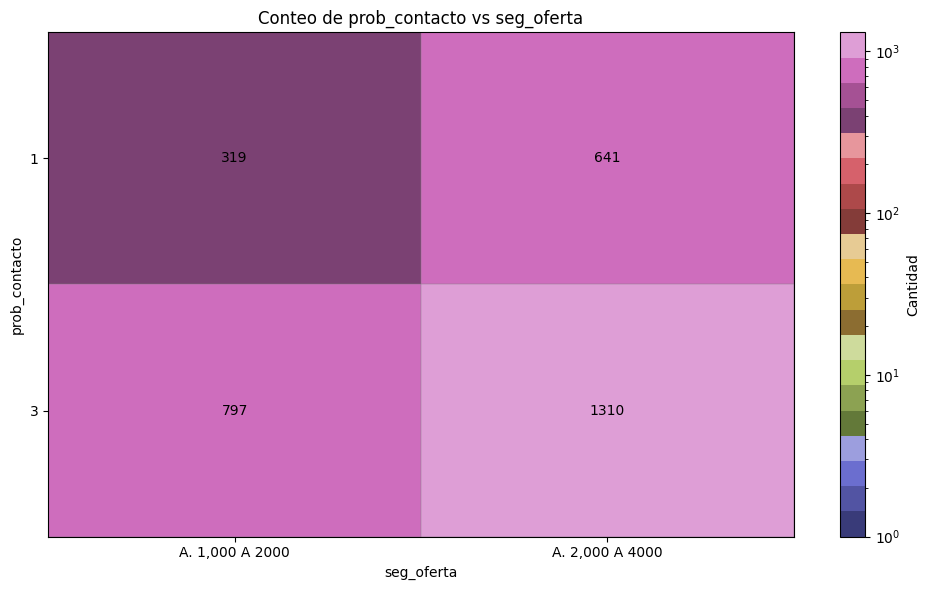

In [14]:
from pyspark.sql import functions as F
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LogNorm
df_plot = (
    df_filtrado.groupBy("prob_contacto", "seg_oferta")
    .count()
)

pdf = df_plot.toPandas()

pdf["seg_oferta"] = pdf["seg_oferta"].fillna("NULL").astype(str)
pdf["prob_contacto"] = pdf["prob_contacto"].fillna("NULL").astype(str)

tabla = pdf.pivot(index="prob_contacto", columns="seg_oferta", values="count").fillna(0)
tabla = tabla.sort_index()
tabla = tabla.reindex(sorted(tabla.columns, key=lambda x: str(x)), axis=1)

fig, ax = plt.subplots(figsize=(10, 6))

# im = ax.imshow(tabla.values, aspect="auto")
im = ax.imshow(
    tabla.values,
    aspect="auto",
    cmap="tab20b",
    norm=LogNorm(vmin=1, vmax=tabla.values.max())
)

ax.set_xticks(np.arange(-.5, len(tabla.columns), 1), minor=True)
ax.set_yticks(np.arange(-.5, len(tabla.index), 1), minor=True)
ax.grid(which="minor", color="gray", linestyle='-', linewidth=0.3)
ax.tick_params(which="minor", bottom=False, left=False)

ax.set_title("Conteo de prob_contacto vs seg_oferta")
ax.set_xlabel("seg_oferta")
ax.set_ylabel("prob_contacto")

ax.set_xticks(np.arange(len(tabla.columns)))
ax.set_xticklabels(tabla.columns)
ax.set_yticks(np.arange(len(tabla.index)))
ax.set_yticklabels(tabla.index)

# mostrar etiquetas dentro de cada celda
for i in range(tabla.shape[0]):
    for j in range(tabla.shape[1]):
        ax.text(j, i, int(tabla.iloc[i, j]), ha="center", va="center")

plt.colorbar(im, ax=ax, label="Cantidad")
plt.tight_layout()
plt.show()

In [15]:
spark.stop()

In [13]:
df_filtrado.groupBy('prob_contacto') \
    .count() \
   .orderBy('prob_contacto') \
    .show(30, truncate=False)

+-------------+-----+
|prob_contacto|count|
+-------------+-----+
|1            |1079 |
|2            |438  |
|3            |2613 |
|5            |1679 |
|6            |457  |
|7            |66   |
+-------------+-----+



In [57]:
df_filtrado.show(truncate=False)

+----------------+------------+-----+----------+---------+-------------+--------+-------------------------+----+--------+---------------------+----------------+--------+-----------------+--------------+----------------+----------+----------+---------------+------+------+-----+--------------+-------------+-----+------+-----+-----+-----+------+-----+-----+-----+--------+-----+-----+-----+-----+-----+-----+-----+--------+----------+---------+------+--------+---------+----+------+------+--------+--------+--------+--------------+-----+------+------------+-----------+---------+-------------+---------+-------------+-----------+----------+----+---------------+-----------+-----+-----------+----+---------------+-------------+-------------------+----------+---------------+--------------+---------+---------------------+---------------------+---------------------+--------------+-------------------+-------------------+-----------------------+------------+----------------------+----------------------

In [20]:
df_filtrado.groupBy('marca3') \
   .count() \
   .orderBy('count', ascending=False) \
   .show(30, truncate=False)

   

+------+-----+
|marca3|count|
+------+-----+
|NUEVO |2475 |
|STOCK |642  |
+------+-----+



In [ ]:
pos cli no no desembolsaron


In [66]:
mejor15_estado_tipi_telf

['CONTACTO EFECTIVO']

In [28]:
city=['CASH BACK se-m']


In [22]:
from pyspark.sql import functions as F
from pyspark.sql.window import Window

w = Window.partitionBy('bench','prob_contacto',"segmentacion",'seg_oferta').orderBy(F.rand())

df_split = df_filtrado.withColumn("grupo_split", F.ntile(2).over(w))

df_parte_1 = df_split.filter(F.col("grupo_split") == 1).drop("grupo_split")
df_parte_2 = df_split.filter(F.col("grupo_split") == 2).drop("grupo_split")
# df_parte_3 = df_split.filter(F.col("grupo_split") == 3).drop("grupo_split")
# df_parte_3 = df_split.filter(F.col("grupo_split") == 3).drop("grupo_split")
# df_parte_4 = df_split.filter(F.col("grupo_split") == 4).drop("grupo_split")
# df_parte_5 = df_split.filter(F.col("grupo_split") == 5).drop("grupo_split")
# df_parte_6 = df_split.filter(F.col("grupo_split") == 6).drop("grupo_split")
# df_parte_7 = df_split.filter(F.col("grupo_split") == 7).drop("grupo_split")

print(
    df_parte_1.count(),
    df_parte_2.count()
    # df_parte_3.count()
    # df_parte_4.count(),
    # df_parte_5.count(),
    # df_parte_6.count(),
    # df_parte_7.count()
)

2577 2498


In [ ]:
['vendor_lead_code', 'phone_number', 'title', 'first_name', 'last_name', 'address1', 'address2', 'address3', 'city', 'province', 'email', 'security_phrase', 'comments', 'mejor_codigo_telf', 'ult_codigo_cli', 'mejor_codigo_cli', 'indice_num', 'tipo_telf', 'indice_tpo_telf', 'tea', 'tea_df', 'tcea', 'tcea_cuotas_df', 'linea_credito', 'l_bcp', 'l_bbva', 'l_ibk', 'l_sco', 'l_bif', 'l_citi', 'l_fin', 'l_rip', 'l_cmr', 'l_cresco', 'l_cen', 'l_azt', 'l_uno', 'l_gnb', 'l_efe', 'l_com', 'l_nac', 'straming', 'fec_nac', 'prioridad', 'priori', 'servicio', 'marca', 'prfl', 'n_base', 'marca3', 'recurr1m', 'recurr2m', 'recurr3m', 'conjunto3meses', 'numtc', 'piloto', 'segmentacion', 'fecha_envio', 'provincia', 'prob_contacto', 'retiro', 'recurrencia3m', 'monto_title', 'seg_edad', 'edad', 'seg_oferta', 'call_result', 'tramo', 'descripcion', 'peso', 'ult_call_result', 'fecha_llamada', 'fecha_hora_llamada', 'q_intentos', 'q_intentos_telf', 'q_intentos_dia', 'dni_unico', 'mejor_estado_tipi_cli', 'mejor_descripcion_cli', 'mejor_sub_descripcion', 'mejor_peso_cli', 'ult_estado_tipi_cli', 'ult_descripcion_cli', 'ult_sub_descripcion_cli', 'ult_peso_cli', 'mejor_estado_tipi_telf', 'mejor_descripcion_telf', 'mejor_sub_descripcion_telf', 'mejor_peso_telf', 'bench']

['vendor_lead_code', 'phone_number', 'title', 'first_name', 'last_name', 'address1', 'address2', 'address3', 'city', 'province', 'email', 'security_phrase', 'comments', 'mejor_codigo_telf', 'ult_codigo_cli', 'mejor_codigo_cli', 'indice_num', 'tipo_telf', 'indice_tpo_telf', 'tea', 'tea_df', 'tcea', 'tcea_cuotas_df', 'linea_credito', 'l_bcp', 'l_bbva', 'l_ibk', 'l_sco', 'l_bif', 'l_citi', 'l_fin', 'l_rip', 'l_cmr', 'l_cresco', 'l_cen', 'l_azt', 'l_uno', 'l_gnb', 'l_efe', 'l_com', 'l_nac', 'straming', 'fec_nac', 'prioridad', 'priori', 'servicio', 'marca', 'prfl', 'n_base', 'marca3', 'recurr1m', 'recurr2m', 'recurr3m', 'conjunto3meses', 'numtc', 'piloto', 'segmentacion', 'fecha_envio', 'provincia', 'prob_contacto', 'retiro', 'recurrencia3m', 'monto_title', 'seg_edad', 'edad', 'seg_oferta', 'call_result', 'tramo', 'descripcion', 'peso', 'ult_call_result', 'fecha_llamada', 'fecha_hora_llamada', 'q_intentos', 'q_intentos_telf', 'q_intentos_dia', 'dni_unico', 'mejor_estado_tipi_cli', 'mejor_de

In [15]:
print([row['mejor_descripcion_cli' ] for row in df_filtrado.select('mejor_descripcion_cli').distinct().collect()])


['MALA EXPERIENCIA', 'POR SEGURO DE DESGRAVAMEN ', 'POR LINEA DE CREDITO', 'TASA DE INTERES ALTA', 'DESEA EFECTIVO  - TIENE UN PRESTAMO', 'CLIENTE NO ESCUCHA OFERTA', 'TELEFONO APAGADO', 'CLIENTE CORTO DESPUES DE ESCUCHAR OFERTA', 'CONTACTO CON TERCERO (CONOCE AL TITULAR)', 'ACEPTA ENVIO WHATSAPP', 'OCUPADO', 'PROGRAMA DE RECOMPENSAS', 'CLIENTE CORTO SIN ESCUCHAR OFERTA', 'CONTACTO CON TERCERO ( NO CONOCE AL TITULAR)', 'SE ENCUENTRA DE VIAJE', 'CLIENTE NO ESCUCHA OFERTA - TITULAR OCUPADO', 'CLIENTE NO ESCUCHA OFERTA - ACEPTA WHATSAPP', 'LLAMADA CORTADA/ERROR DE COMUNICACION', 'NO CONTESTA', 'PREFIERE SU PROPIO BANCO', 'TITULAR DESEA QUE VUELVAN A LLAMAR', 'NO DESEA DAR MOTIVOS']


In [ ]:
['MALA EXPERIENCIA',
 'POR SEGURO DE DESGRAVAMEN ',
 'POR LINEA DE CREDITO',
 'TASA DE INTERES ALTA',
 'DESEA EFECTIVO  - TIENE UN PRESTAMO',
 'CLIENTE NO ESCUCHA OFERTA',
 'TELEFONO APAGADO',
 'CLIENTE CORTO DESPUES DE ESCUCHAR OFERTA',
 'CONTACTO CON TERCERO (CONOCE AL TITULAR)',
 'ACEPTA ENVIO WHATSAPP',
 'OCUPADO',
 'PROGRAMA DE RECOMPENSAS',
 'CLIENTE CORTO SIN ESCUCHAR OFERTA',
 'CONTACTO CON TERCERO ( NO CONOCE AL TITULAR)',
 'SE ENCUENTRA DE VIAJE',
 'CLIENTE NO ESCUCHA OFERTA - TITULAR OCUPADO',
 'CLIENTE NO ESCUCHA OFERTA - ACEPTA WHATSAPP',
 'LLAMADA CORTADA/ERROR DE COMUNICACION',
 'NO CONTESTA',
 'PREFIERE SU PROPIO BANCO',
 'TITULAR DESEA QUE VUELVAN A LLAMAR',
 'NO DESEA DAR MOTIVOS']

In [17]:
fecha_mes_base='2026-07-01'
tipi_cond1='EFECTIVA_NC'
tipi_cond2='xx'
tipi_cond3='xx'
tb_tipolofia='tTipologia_Efectiva'
servidor_01=7
tipi_cod='Codigo'
tipi_resp_cod='B0'
tipi_descrip='DESCRIPCION'
tipi_estado='tipo'
tipi_resp_estado='NO CONTACTO'
tipi_subdescripcion='SUB_DESCRIPCION'
tnum_tb='tNumeroEfectiva'
tnum_dni='DNI'
tlista_generada='borrar_efe_consumo'
get_base=since_base_maestra_efe_consumo

def resumen_vicidial(spark,fecha_mes_base,tipi_cond1,tipi_cond2,tipi_cond3,tb_tipolofia,servidor_01,tipi_cod,tipi_resp_cod,tipi_descrip,tipi_estado,tipi_resp_estado):
    query = f"""
        SELECT *
        FROM OPENQUERY([192.168.3.{servidor_01}], '
            SELECT        
            rtrim(ltrim(d.vendor_lead_code)) AS vendor_lead_code,        
            e.dial_method,
            a.campaign_id AS numero_campana,        
            a.user AS dni_ejecutivo,
            c.full_name AS ejecutivo,
            e.campaign_name AS nombre_campana,        
            a.call_date AS fecha_hora_llamada,        
            a.length_in_sec AS duracion,        
            b.status_name AS call_result,        
            f.list_description,        
            f.list_name,        
            a.phone_number as phone_number,        
            d.alt_phone as fecha_agenda,        
            d.comments as comentarios,        
            a.status AS codigo,
            a.term_reason,	
            a.alt_dial
            FROM asterisk.vicidial_log a         
            LEFT JOIN asterisk.vicidial_list d ON a.lead_id=d.lead_id        
            LEFT JOIN asterisk.vicidial_campaigns e ON a.campaign_id=e.campaign_id        
            LEFT JOIN asterisk.vicidial_lists f ON a.list_id=f.list_id        
            LEFT JOIN asterisk.vicidial_statuses b ON a.status=b.status        
            LEFT JOIN asterisk.vicidial_users c ON a.user=c.user        
            WHERE (e.campaign_name like "%{tipi_cond1}" or e.campaign_name like "%{tipi_cond2}" or e.campaign_name like "%{tipi_cond3}")
            AND a.call_date >= ''2026-07-09''
            AND a.call_date < 
            DATE_ADD(DATE_FORMAT(''{fecha_mes_base}'', ''%Y-%m-01''), INTERVAL 1 MONTH)
        ')

        """
    df_vicidial=obtener_tabla_sql(spark,query,server_zeus,user_zeus,pwd_zeus,db_zeus)

    df_vicidial = df_vicidial.withColumn(
        "vendor_lead_code",
        F.lpad(F.col("vendor_lead_code").cast("string"), 8, "0")
    )
    query = f"""
        SELECT {tipi_cod} as codigo
        , case
            when {tipi_cod}='CALLBK' then 'VOLVER A LLAMAR - call'
            else {tipi_descrip} 
        end as descripcion
        ,case 
            when {tipi_cod}='CALLBK' then 1200
            else peso 
        end as peso  FROM [ODIN].[dbo].{tb_tipolofia}
        where LEFT({tipi_cod},2)='{tipi_resp_cod}' or {tipi_estado}='{tipi_resp_estado}' or {tipi_cod}='CALLBK'
        """
    df_tipi=obtener_tabla_sql(spark,query,server_zeus,user_zeus,pwd_zeus,db_zeus)

    df_vicidial=df_vicidial.join(df_tipi,["codigo"],"left")

    return df_vicidial.select('fecha_hora_llamada','list_name','vendor_lead_code','phone_number','descripcion','dni_ejecutivo','ejecutivo','dial_method','term_reason','alt_dial','call_result','duracion','codigo','nombre_campana')

df_vici=resumen_vicidial(spark,fecha_mes_base,tipi_cond1,tipi_cond2,tipi_cond3,tb_tipolofia,servidor_01,tipi_cod,tipi_resp_cod,tipi_descrip,tipi_estado,tipi_resp_estado)
# df_vici.filter(F.col('vendor_lead_code')=='45914692').orderBy(F.col('fecha_hora_llamada').desc()).show(truncate=False)


In [16]:
df_list_filtrada = df_filtrado.toPandas()
ruta_archivo = os.path.join(ruta_csv, 'asdasdasdasdas_____________.xlsx')
df_list_filtrada.to_excel(ruta_archivo, index=False)

In [13]:
df_filtrado_1=df_filtrado.dropDuplicates(['vendor_lead_code'])

In [16]:
df_list_filtrada = df_filtrado_1.toPandas()
ruta_archivo = os.path.join(ruta_csv, 'todo.xlsx')
df_list_filtrada.to_excel(ruta_archivo, index=False)

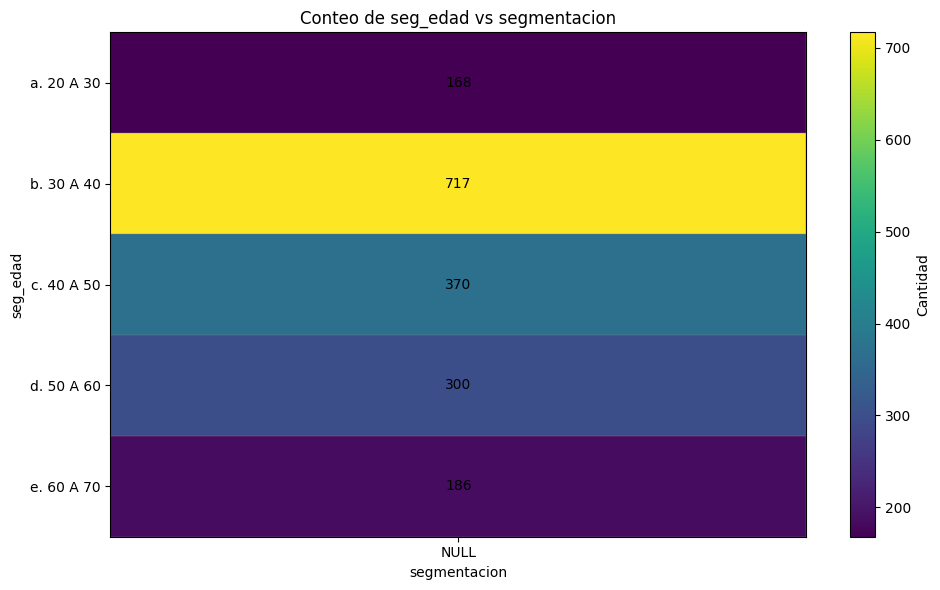

In [50]:
from pyspark.sql import functions as F
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
df_plot = (
    df_filtrado.groupBy("seg_edad", "segmentacion")
    .count()
)

pdf = df_plot.toPandas()

pdf["segmentacion"] = pdf["segmentacion"].fillna("NULL").astype(str)
pdf["seg_edad"] = pdf["seg_edad"].fillna("NULL").astype(str)

tabla = pdf.pivot(index="seg_edad", columns="segmentacion", values="count").fillna(0)
tabla = tabla.sort_index()
tabla = tabla.reindex(sorted(tabla.columns, key=lambda x: str(x)), axis=1)

fig, ax = plt.subplots(figsize=(10, 6))

# im = ax.imshow(tabla.values, aspect="auto")
# im = ax.imshow(tabla.values, aspect="auto", cmap="YlGnBu")
im = ax.imshow(tabla.values, aspect="auto")
# im = ax.imshow(tabla.values, aspect="auto", cmap="YlOrRd")
# im = ax.imshow(
#     tabla.values,
#     aspect="auto",
#     cmap="YlGnBu",
#     vmin=0,
#     vmax=np.percentile(tabla.values, 90)   # 👈 clave
# )
# )
ax.set_xticks(np.arange(-.5, len(tabla.columns), 1), minor=True)
ax.set_yticks(np.arange(-.5, len(tabla.index), 1), minor=True)
ax.grid(which="minor", color="gray", linestyle='-', linewidth=0.3)
ax.tick_params(which="minor", bottom=False, left=False)

ax.set_title("Conteo de seg_edad vs segmentacion")
ax.set_xlabel("segmentacion")
ax.set_ylabel("seg_edad")

ax.set_xticks(np.arange(len(tabla.columns)))
ax.set_xticklabels(tabla.columns)
ax.set_yticks(np.arange(len(tabla.index)))
ax.set_yticklabels(tabla.index)

# mostrar etiquetas dentro de cada celda
for i in range(tabla.shape[0]):
    for j in range(tabla.shape[1]):
        ax.text(j, i, int(tabla.iloc[i, j]), ha="center", va="center")

plt.colorbar(im, ax=ax, label="Cantidad")
plt.tight_layout()
plt.show()

In [87]:
df_list_filtrada = df_filtrado.select(
    'vendor_lead_code', 'phone_number', 'title', 'first_name',
    'last_name', 'address1', 'address2', 'address3',
    'city', 'province', 'email', 'security_phrase', 'comments'
).toPandas()
ruta_archivo = os.path.join(ruta_csv, 'tc.xlsx')
df_list_filtrada.to_excel(ruta_archivo, index=False)

In [82]:
df_list_filtrada = df_list.select.toPandas()
ruta_archivo = os.path.join(ruta_csv, 'tc.xlsx')
df_list_filtrada.to_excel(ruta_archivo, index=False)

AttributeError: 'function' object has no attribute 'toPandas'

In [ ]:
df_filtrado.groupBy('marca') \
   .count() \
   .orderBy('count', ascending=False) \
   .show(30, truncate=False)

   

+-------------+-----+
|prob_contacto|count|
+-------------+-----+
|4            |1563 |
|3            |656  |
|2            |401  |
|1            |137  |
|2+           |50   |
+-------------+-----+



In [11]:
df_filtrado.groupBy('prob_contacto') \
    .count() \
   .orderBy('prob_contacto') \
    .show(30, truncate=False)

+-------------+-----+
|prob_contacto|count|
+-------------+-----+
|4            |1    |
|5            |973  |
|6            |823  |
|7            |396  |
+-------------+-----+



In [8]:
city=['CASH BACK se-m']



In [4]:
print([row['segmentacion' ] for row in df_list.select('segmentacion').distinct().collect()])


['2.ELITE', '3.PREMIUM', '5.BASE', '6.JOVEN PROFESIONAL_A']


In [14]:
print(df_filtrado.columns)

['vendor_lead_code', 'phone_number', 'title', 'first_name', 'last_name', 'address1', 'address2', 'address3', 'city', 'province', 'email', 'security_phrase', 'comments', 'mejor_codigo_telf', 'ult_codigo_cli', 'mejor_codigo_cli', 'indice_num', 'tipo_telf', 'indice_tpo_telf', 'tea', 'tea_df', 'tcea', 'tcea_cuotas_df', 'linea_credito', 'l_bcp', 'l_bbva', 'l_ibk', 'l_sco', 'l_bif', 'l_citi', 'l_fin', 'l_rip', 'l_cmr', 'l_cresco', 'l_cen', 'l_azt', 'l_uno', 'l_gnb', 'l_efe', 'l_com', 'l_nac', 'straming', 'fec_nac', 'prioridad', 'priori', 'servicio', 'marca', 'prfl', 'n_base', 'marca3', 'recurr1m', 'recurr2m', 'recurr3m', 'conjunto3meses', 'numtc', 'piloto', 'segmentacion', 'fecha_envio', 'provincia', 'prob_contacto', 'retiro', 'recurrencia3m', 'monto_title', 'seg_edad', 'seg_oferta', 'call_result', 'tramo', 'descripcion', 'peso', 'ult_call_result', 'fecha_llamada', 'fecha_hora_llamada', 'q_intentos', 'q_intentos_telf', 'q_intentos_dia', 'dni_unico', 'mejor_estado_tipi_cli', 'mejor_descripcio

In [ ]:
||['vendor_lead_code', 'phone_number', 'title', 'first_name', 'last_name', 'address1', 'address2', 'address3', 'city', 'province', 'email', 'security_phrase', 'comments', 'mejor_codigo_telf', 'ult_codigo_cli', 'mejor_codigo_cli', 'indice_num', 'tipo_telf', 'indice_tpo_telf', 'tea', 'tea_df', 'tcea', 'tcea_cuotas_df', 'linea_credito', 'l_bcp', 'l_bbva', 'l_ibk', 'l_sco', 'l_bif', 'l_citi', 'l_fin', 'l_rip', 'l_cmr', 'l_cresco', 'l_cen', 'l_azt', 'l_uno', 'l_gnb', 'l_efe', 'l_com', 'l_nac', 'straming', 'fec_nac', 'prioridad', 'priori', 'servicio', 'marca', 'prfl', 'n_base', 'marca3', 'recurr1m', 'recurr2m', 'recurr3m', 'conjunto3meses', 'numtc', 'piloto', 'segmentacion', 'fecha_envio', 'provincia', 'prob_contacto', 'retiro', 'recurrencia3m', 'monto_title', 'seg_edad', 'seg_oferta', 'call_result', 'tramo', 'descripcion', 'peso', 'ult_call_result', 'fecha_llamada', 'fecha_hora_llamada', 'q_intentos', 'q_intentos_telf', 'q_intentos_dia', 'dni_unico', 'mejor_estado_tipi_cli', 'mejor_descripcion_cli', 'mejor_sub_descripcion', 'mejor_peso_cli', 'ult_estado_tipi_cli', 'ult_descripcion_cli', 'ult_sub_descripcion_cli', 'ult_peso_cli', 'mejor_estado_tipi_telf', 'mejor_descripcion_telf', 'mejor_sub_descripcion_telf', 'mejor_peso_telf', 'bench']fec

In [ ]:
from pyspark.sql import functions as F|||

df_filtrado = df_filtrado.withColumn(
    "fec_nac_date",
    F.to_date(F.col("fec_nac"), "d/MM/yyyy")
)
df_filtrado = df_filtrado.withColumn(
    "edad",
    F.floor(F.months_between(F.current_date(), F.col("fec_nac_date")) / 12)
)

In [8]:
df_filtrado=df_filtrado.filter(col('edad').between(30,60))

+-----------+-----+
|fecha_envio|count|
+-----------+-----+
|2026-04-01 |1577 |
+-----------+-----+



In [25]:
df_filtrado.count()

3276

In [41]:
spark.stop()

In [112]:
df_filtrado.groupBy('n_base') \
    .count() \
    .orderBy('count', ascending=False) \
    .show(30, truncate=False)

+-------+-----+
|n_base |count|
+-------+-----+
|Alpha  |2654 |
|Beta   |748  |
|Sigma  |508  |
|Gamma  |338  |
|Alpha 2|89   |
|Zeta   |57   |
+-------+-----+



+---------------+-----+
|q_intentos_telf|count|
+---------------+-----+
|3              |5    |
|4              |15   |
|5              |33   |
|6              |34   |
|7              |69   |
|8              |303  |
|9              |288  |
|10             |426  |
|11             |398  |
|12             |48   |
|13             |30   |
|14             |14   |
|15             |5    |
|16             |4    |
|17             |4    |
|18             |1    |
|20             |1    |
|22             |1    |
+---------------+-----+



In [9]:
df_list_filtrada = df_filtrado.select(
    'vendor_lead_code', 'phone_number', 'title', 'first_name',
    'last_name', 'address1', 'address2', 'address3',
    'city', 'province', 'email', 'security_phrase', 'comments'
).toPandas()
ruta_archivo = os.path.join(ruta_csv, 'tc_dinner_20260418.xlsx')
df_list_filtrada.to_excel(ruta_archivo, index=False)

In [265]:
df_plot=df_filtrado.toPandas()

In [113]:
df_filtrado.groupBy('bench') \
    .count() \
    .orderBy('bench') \
    .show()

+------+-----+
| bench|count|
+------+-----+
| Otros|  698|
|l_bbva| 1155|
| l_bcp| 1442|
| l_ibk|  789|
| l_sco|  310|
+------+-----+



In [15]:
df_filtrado.groupBy('seg_edad') \
    .count() \
    .orderBy('seg_edad') \
    .show()

+----------+-----+
|  seg_edad|count|
+----------+-----+
|1. 20 A 30|   94|
|2. 30 A 40| 1304|
|3. 40 A 50|  526|
|4. 50 A 60|  566|
|5. 60 A 70|  347|
+----------+-----+



In [16]:
df_filtrado.groupBy('title') \
    .count() \
    .orderBy('title') \
    .show()

+------+-----+
| title|count|
+------+-----+
|l_bbva| 2218|
| l_bcp|    6|
| l_ibk|    1|
| l_sco|  612|
+------+-----+



In [299]:
print([row['seg_edad' ] for row in df_list.select('seg_edad').distinct().collect()])


['3. 40 A 50', '5. 60 A 70', '4. 50 A 60', '2. 30 A 40', '1. 20 A 30']


In [140]:
df_filtrado.show()

+----------------+------------+---------------+-----+----------+---------+-------------+--------+--------------------+----+--------+-----------------+----------------+--------+--------------------+-------------------+------------------+----------------+----------+----------+-----------+----------------+---------------+----------+---------------+---+------+-----+--------------+-------------+--------+----------+---------+------+--------+---------+----+------+------+--------+--------+--------+--------------+-----+------+-----------+---------+-------------+-------------+-----------+----------+----------------+---------+--------------+-----------------+-------------------+--------+--------------------+--------------------+------------+-----------+-------------+-----+-------------+------------------+--------------------+---------+---------------------+---------------------+---------------------+--------------+-----------------------+-----------------------+---------------------------+-------

In [133]:
fecha_mes_base='2026-04-01'
ls_una_vez = ['AB','ADC','ADCT','B036','B037','B038']
ls_ocupado = ['AA','B033','B034','B035','DCMX','DROP','DISPO','DONEM','NA','PDROP','QUEUE','INCALL']
ls_casilla = ['no_hay_nada']
tipi_cond1='DINERS TC'
tipi_cond2='xx'
tipi_cond3='xx'
tipi_tb='tTipologia_Diners_TC'
servidor_01=21
tipi_cod='cod'
tipi_resp_cod='H'
tipi_descrip='[NIVEL 4]'
tipi_estado='[NIVEL 2]'
tipi_resp_estado='NO CONTACTO'
tipi_subdescripcion='[NIVEL 3]'
tnum_tb='tNumeroDinersTc'
tnum_dni='NUMERO_DOCUMENTO'
tlista_generada='borrar_df_tc_dinner_01'
get_base=since_base_maestra_tc_dinners
df_vicidial=since_vicidial(spark,fecha_mes_base,tipi_cond1,tipi_cond2,tipi_cond3,tipi_tb,servidor_01,tipi_cod,tipi_resp_cod,tipi_descrip,tipi_estado,tipi_resp_estado)


In [135]:
df_vicidial.filter((col('phone_number')=='995158165')&
(col('fecha_llamada')=='2026-04-09')).show()

+----------------+--------------+-----------------+-------------------+--------+--------------------+--------------------+------------+-----------+-------------+-----+----------------+----+------------+------+-------------+--------------------+-----------+-------------+------------------+----------------+----------------+--------------------+--------------------+
|vendor_lead_code|numero_campana|   nombre_campana| fecha_hora_llamada|duracion|         call_result|           list_name|fecha_agenda|comentarios|fecha_llamada|tramo|mejor_CODIGO_cli|PESO|phone_number|CODIGO|n_mejor_resul|mejor_CODIGO_cli_dia|cod_attempt|dni_ejecutivo|         ejecutivo|q_intentos_telef|     DESCRIPCION|         dial_method|     ult_call_result|
+----------------+--------------+-----------------+-------------------+--------+--------------------+--------------------+------------+-----------+-------------+-----+----------------+----+------------+------+-------------+--------------------+-----------+------------

In [20]:
df_filtrado.groupBy('linea_credito').count().show()

+-------------+-----+
|linea_credito|count|
+-------------+-----+
|      3500.00|   37|
|      7600.00|    3|
|      3900.00|   29|
|     12600.00|    1|
|      8900.00|    4|
|     11000.00|    2|
|      3200.00|   28|
|      6800.00|    9|
|     14500.00|    2|
|      9200.00|    4|
|      5400.00|   31|
|      3600.00|   24|
|      6200.00|   17|
|      1800.00|   10|
|     11100.00|    2|
|     13800.00|    1|
|      6700.00|   14|
|      4800.00|   50|
|     17400.00|    1|
|     16600.00|    1|
+-------------+-----+
only showing top 20 rows


In [ ]:
from pyspark.sql import functions as F

df_base = df_filtrado.withColumn(
    "lista_objetivo",
    F.when(
        ((F.col("prob_contacto") == 1)|(F.col("prob_contacto").isNull()) ) &
        (F.col("linea_credito").between(1000,2000)),
        "1"
    ).when(
        (F.col("prob_contacto").isin(2)) ,
        "2"
    ).when(
        (F.col("prob_contacto").isin(1,2,4)) &
        ((F.col("linea_credito").between(4000,4000))|(F.col("linea_credito").between(8000,10000))),
        "3"
    ).otherwise("4")
)
df_base.groupBy("lista_objetivo").count().orderBy("lista_objetivo").show()

+--------------+-----+
|lista_objetivo|count|
+--------------+-----+
|             1| 1000|
|             2| 2285|
|             3| 6724|
|             4| 5773|
+--------------+-----+



In [ ]:
['vendor_lead_code', 'phone_number', 'phone_number_02', 'title', 'first_name', 'last_name', 'address1', 'address2', 'address3', 'city', 'province', 'email', 'security_phrase', 'comments', 'min_numero', 'phone_number_04', 'tea', 'tea_df', 'tcea', 'tcea_cuotas_df', 'linea_credito', 'straming', 'fec_nac', 'prioridad', 'priori', 'servicio', 'marca', 'prfl', 'n_base', 'marca3', 'recurr1m', 'recurr2m', 'recurr3m', 'conjunto3meses', 'numtc', 'piloto', 'fecha_envio', 'provincia', 'prob_contacto', 'recurrencia3m', 'monto_title', 'seg_edad', 'seg_oferta', 'retiro_01', 'numero_campana', 'nombre_campana', 'fecha_hora_llamada', 'duracion', 'call_result', 'list_name', 'fecha_agenda', 'comentarios', 'fecha_llamada', 'tramo', 'dni_ejecutivo', 'ejecutivo', 'ult_call_result', 'dni_unico', 'mejor_estado_tipi_cli', 'mejor_descripcion_cli', 'mejor_sub_descripcion', 'mejor_peso_cli', 'mejor15_estado_tipi_cli', 'mejor15_descripcion_cli', 'mejor15_sub_descripcion_cli', 'mejor15_peso_cli', 'mejor15_estado_tipi_telf', 'mejor15_descripcion_telf', 'mejor15_sub_descripcion_telf', 'mejor15_peso_telf', 'mejor_estado_tipi_cli_dia', 'mejor_descripcion_cli_dia', 'mejor_sub_descripcion_cli_dia', 'mejor_peso_cli_dia']contac


In [223]:
# print([row['title' ] for row in df_list.select('title').distinct().collect()])
# print([row['first_name' ] for row in df_list.select('first_name').distinct().collect()])
# print([row['marca' ] for row in df_list.select('marca').distinct().collect()])
# print([row['marca3' ] for row in df_list.select('marca3').distinct().collect()])
# print([row['last_name' ] for row in df_list.select('last_name').distinct().collect()])
# print([row['address2' ] for row in df_list.select('address2').distinct().collect()])
# print([row['prob_contacto' ] for row in df_list.select('prob_contacto').distinct().collect()])


{"ts": "2026-04-09 15:33:56.829", "level": "ERROR", "logger": "DataFrameQueryContextLogger", "msg": "[UNRESOLVED_COLUMN.WITH_SUGGESTION] A column, variable, or function parameter with name `recurrncia` cannot be resolved. Did you mean one of the following? [`recurr1m`, `recurr2m`, `recurr3m`, `recurrencia3m`, `provincia`]. SQLSTATE: 42703", "context": {"file": "jdk.internal.reflect.GeneratedMethodAccessor34.invoke(Unknown Source)", "line": "", "fragment": "col", "errorClass": "UNRESOLVED_COLUMN.WITH_SUGGESTION"}, "exception": {"class": "Py4JJavaError", "msg": "An error occurred while calling o13672.select.\n: org.apache.spark.sql.AnalysisException: [UNRESOLVED_COLUMN.WITH_SUGGESTION] A column, variable, or function parameter with name `recurrncia` cannot be resolved. Did you mean one of the following? [`recurr1m`, `recurr2m`, `recurr3m`, `recurrencia3m`, `provincia`]. SQLSTATE: 42703;\n'Project ['recurrncia]\n+- Relation [vendor_lead_code#11418,phone_number#11419,phone_number_02#11420,

AnalysisException: [UNRESOLVED_COLUMN.WITH_SUGGESTION] A column, variable, or function parameter with name `recurrncia` cannot be resolved. Did you mean one of the following? [`recurr1m`, `recurr2m`, `recurr3m`, `recurrencia3m`, `provincia`]. SQLSTATE: 42703;
'Project ['recurrncia]
+- Relation [vendor_lead_code#11418,phone_number#11419,phone_number_02#11420,title#11421,first_name#11422,last_name#11423,address1#11424,address2#11425,address3#11426,city#11427,province#11428,email#11429,security_phrase#11430,comments#11431,mejor_CODIGO_cli_dia#11432,mejor15_CODIGO_telf#11433,mejor15_CODIGO_cli#11434,mejor_CODIGO_cli#11435,indice_num#11436L,tipo_telf#11437,cod_attempt#11438L,q_intentos_telef#11439L,indice_tpo_telf#11440,min_numero#11441,phone_number_04#11442,... 58 more fields] JDBCRelation((
    select * from cronox.dbo.borrar_df_tc_dinner_01
) AS tmp) [numPartitions=1]


In [ ]:
 'CLIENTE ACEPTO OFERTA TC + ADICIONAL (SEGURO)',
 'POR SEGURO DE DESGRAVAMEN ',
 'POR LINEA DE CREDITO',
 'CLIENTE ACEPTO OFERTA TC SIN TRANSFERIR',
 'CLIENTE NO ESCUCHA OFERTA',
 'CLIENTE CORTO DESPUES DE ESCUCHAR OFERTA',
 'CLIENTE ACEPTO OFERTA TC (SEGURO)',
 'CLIENTE DESEA QUE NO VUELVAN A LLAMAR',
 'CONTACTO CON TERCERO (CONOCE AL TITULAR)',
 'ACEPTA ENVIO WHATSAPP',
 'OCUPADO',
 'CLIENTE ACEPTO OFERTA TC + ADICIONAL  SIN TRANSFERIR',
 'NO CALIFICA COMERCIAL',
 'PROGRAMA DE RECOMPENSAS',
 'NO RECONOCE LA MARCA',
 'CLIENTE CORTO SIN ESCUCHAR OFERTA',
 'CONTACTO CON TERCERO ( NO CONOCE AL TITULAR)',
 'SE ENCUENTRA DE VIAJE',
 'CLIENTE NO ESCUCHA OFERTA - TITULAR OCUPADO',
 'CLIENTE NO ESCUCHA OFERTA - ACEPTA WHATSAPP',
 'LLAMADA CORTADA/ERROR DE COMUNICACION',
 'NO CONTESTA',
 'PREFIERE SU PROPIO BANCO',
 'TITULAR DESEA QUE VUELVAN A LLAMAR',
 'NO DESEA DAR MOTIVOS',
 None]


In [ ]:

df_filtrado = df_list.filter(
    ( 
        (F.col('mejor_descripcion_cli').isin(mejor15_descripcion_telf)) |
        (F.col('mejor_descripcion_cli').isNull())
     ) &
    (
        (F.col('mejor15_descripcion_telf').isin(mejor15_descripcion_telf)) | 
        (F.col('mejor15_descripcion_telf').isNull())
    ) &
    (F.lower(F.col('tipo_telf')) == 'bbdd cel01') &
    # (col('first_name').isin(first_name)) &
    (col('title').isin(title)) &
    (col('linea_credito').between(1400,7000)) &
    # (col('peso_inv').isin(peso_inv)) &
    # (col('nomcomercial').isin(nomcomercial)) &
    # (col('rango_tasa').isin(rango_tasa)) &
    (
        (F.col('q_intentos_telef').isNull()) | (F.col('q_intentos_telef')<=10)
    ) &
    (
       (F.col('fecha_llamada').isNull()) | (F.col('fecha_llamada')<='2026-03-30')
    ) 

).orderBy(F.col('linea_credito').desc())

df_filtrado.count()



5818

In [ ]:
df_filtrado = df_filtrado.select(
    'vendor_lead_code', 'phone_number', 'title', 'first_name',
    'last_name', 'address1', 'address2', 'address3',
    'city', 'province', 'email', 'security_phrase', 'comments','mejor15_descripcion_telf'
)
df_dni = df_filtrado.toPandas()
df_dni.count()

ruta_archivo = os.path.join(ruta_csv, 'tc_dinner_202604061256.xlsx')

df_dni.to_excel(ruta_archivo, index=False)

In [11]:

df_dni = df_filtrado.select(
    'vendor_lead_code', 'phone_number', 'title', 'first_name', 'last_name', 'address1', 'address2', 'address3', 'city', 'province', 'email', 'security_phrase', 'comments'
).toPandas()
# orderBy(F.col('linea_hs_plus').desc())


In [12]:

ruta_archivo = os.path.join(ruta_csv, 'tc_dinner_202604061256.xlsx')

df_dni.to_excel(ruta_archivo, index=False)

In [39]:
cantidad_leads=df_filtrado.count()

In [43]:
info_list=f"""
Se tienen {cantidad_leads} leads
perfil: {perfil}
rango tasa: {rango_tasa}
Zona: {zona}
nomcomercial: {nomcomercial}
10 intentos como maximo por telef
montos mayores a 5k
"""

print(info_list)


Se tienen 11182 leads
perfil: ['VP1', '1']
rango tasa: ['g. (80%,90%]', 'h. (90%,+)', 'f. (70%,80%]']
Zona: ['NORTE 2', 'LIMA NORESTE', 'CENTRO', 'NORTE 1', 'NORTE 2', 'SUR ORIENTE', 'LIMA SUR CHICO', 'SUR']
nomcomercial: ['EFECTIVO BANCARIZADO FASTTRACK', 'EFECTIVO BANCARIZADO MLRD', 'EFECTIVO BANCARIZADO PREMIUM', 'NO BANCARIZADO', 'RECURRENTE DORMIDOS']
10 intentos como maximo por telef
montos mayores a 5k



11182

In [17]:
print([row['mejor15_descripcion_telf' ] for row in df_list.select('mejor15_descripcion_telf').distinct().collect()])


['PERSONA FALLECIDA', 'VOLVER A LLAMAR', 'ABONO EN CUENTA', 'LO VA A PENSAR', 'DESEA ELECTRO', 'NEGOCIO EN ZONA NO COBERTURADA', 'CREDITO CONCRETADO', 'NO NECESITA / NO DESEA', 'TELEFONO APAGADO', 'NUMERO EQUIVOCADO', 'ESTA ENDEUDADO', 'OTROS', 'NO CONTESTA ', 'TITULAR NO CALIFICA- GIRO RESTRINGIDO9', 'CLIENTE RECHAZADO', 'MENSAJES CON TERCEROS - OTROS', 'CASA EN ZONA NO COBERTURADA', 'SI QUIERE', 'CLIENTE DE VIAJE', 'TELEFONO FUERA DE SERVICIO/SUSPENDIDO', 'CONFIRMAR CITA', 'INTERESES ELEVADOS', 'NUMERO NO EXISTE', 'TITULAR NO CALIFICA - DESEMPLEO', 'TONO OCUPADO', 'SOLICITA SER RETIRADO', 'MALA EXPERIENCIA (TDA/FNC)', 'DESEA MAS MONTO', 'NO QUIERE', None]


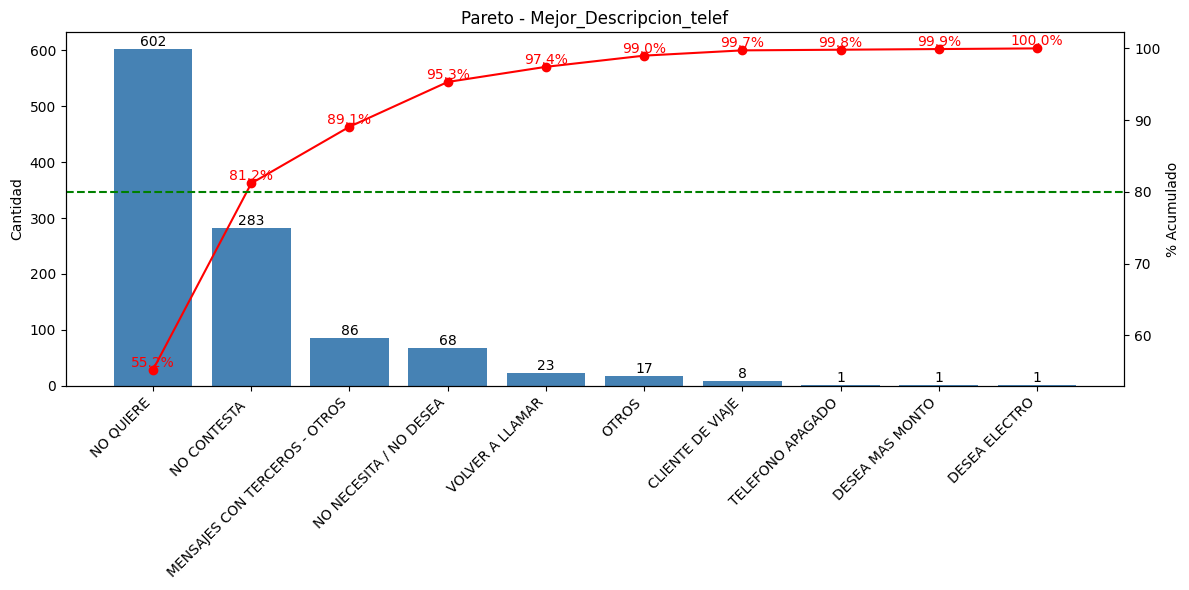

In [12]:
df = df_filtrado.select('mejor15_descripcion_telf').toPandas()
pareto_mejor_descripcion(df,'mejor15_descripcion_telf')

In [42]:
exportar_lista(df_filtrado,'consumo_202603311119.xlsx','linea_hs_plus')


In [35]:
df.count()

mejor15_descripcion_telf    143
dtype: int64

In [36]:
df_dni = df_filtrado.toPandas() 
df_dni.count()

vendor_lead_code                 11182
phone_number                     11182
phone_number_02                  10728
first_name                       11182
last_name                        11182
                                 ...  
mejor15_peso_telf                  143
mejor_estado_tipi_cli_dia         1705
mejor_descripcion_cli_dia         1705
mejor_sub_descripcion_cli_dia     1705
mejor_peso_cli_dia                1705
Length: 86, dtype: int64

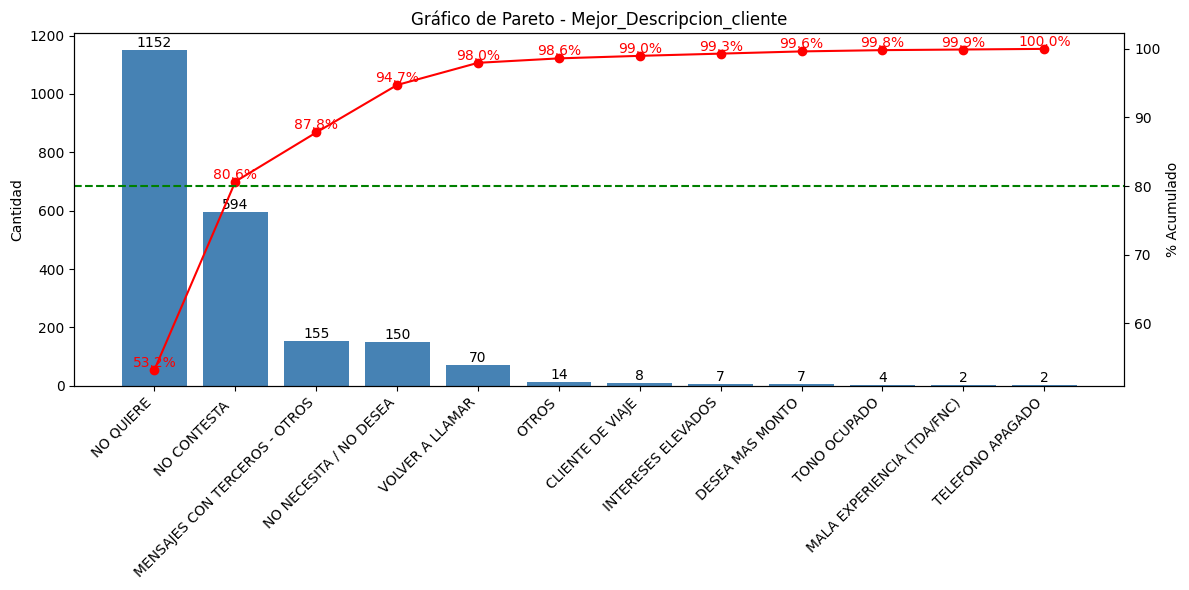

In [37]:
import pandas as pd
import matplotlib.pyplot as plt

# Filtrar SIN GESTION
# df_filtrado = df_cen_sae[
#     ~df_cen_sae["Mejor_Descripcion_Telefono"].str.contains("SIN GESTION", na=False)
# ]
# df_filtrado = df_cen_sae[
#     (~df_cen_sae["Mejor_Descripcion_Telefono"].str.contains("SIN GESTION", na=False)) &
#     (df_cen_sae["Tipo_Telf"].isin(['BBDD CEL01','BBDD CEL03','BBDD CEL02']))&
#     (df_cen_sae["PROPENSION"].isin(['ALTO','BAJO']))
# ]

# Conteo ordenado
conteo = df_dni["mejor_descripcion_cli"] \
            .value_counts() \
            .sort_values(ascending=False)

# % acumulado
porc_acum = conteo.cumsum() / conteo.sum() * 100

fig, ax1 = plt.subplots(figsize=(12,6))

# 🔵 Barras
bars = ax1.bar(conteo.index, conteo.values, color="steelblue")
ax1.set_ylabel("Cantidad")

# 👉 Etiquetas de cantidad en barras
for bar in bars:
    height = bar.get_height()
    ax1.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{int(height)}',
        ha='center',
        va='bottom'
    )

plt.xticks(rotation=45, ha="right")

# 🔴 Línea acumulada
ax2 = ax1.twinx()
ax2.plot(conteo.index, porc_acum, color="red", marker="o")
ax2.set_ylabel("% Acumulado")

# 👉 Etiquetas de % acumulado
for i, txt in enumerate(porc_acum):
    ax2.text(i, txt, f"{txt:.1f}%", color="red", ha="center", va="bottom")

# Línea 80%
ax2.axhline(80, color="green", linestyle="--")

plt.title("Gráfico de Pareto - Mejor_Descripcion_cliente")
plt.tight_layout()
plt.show()

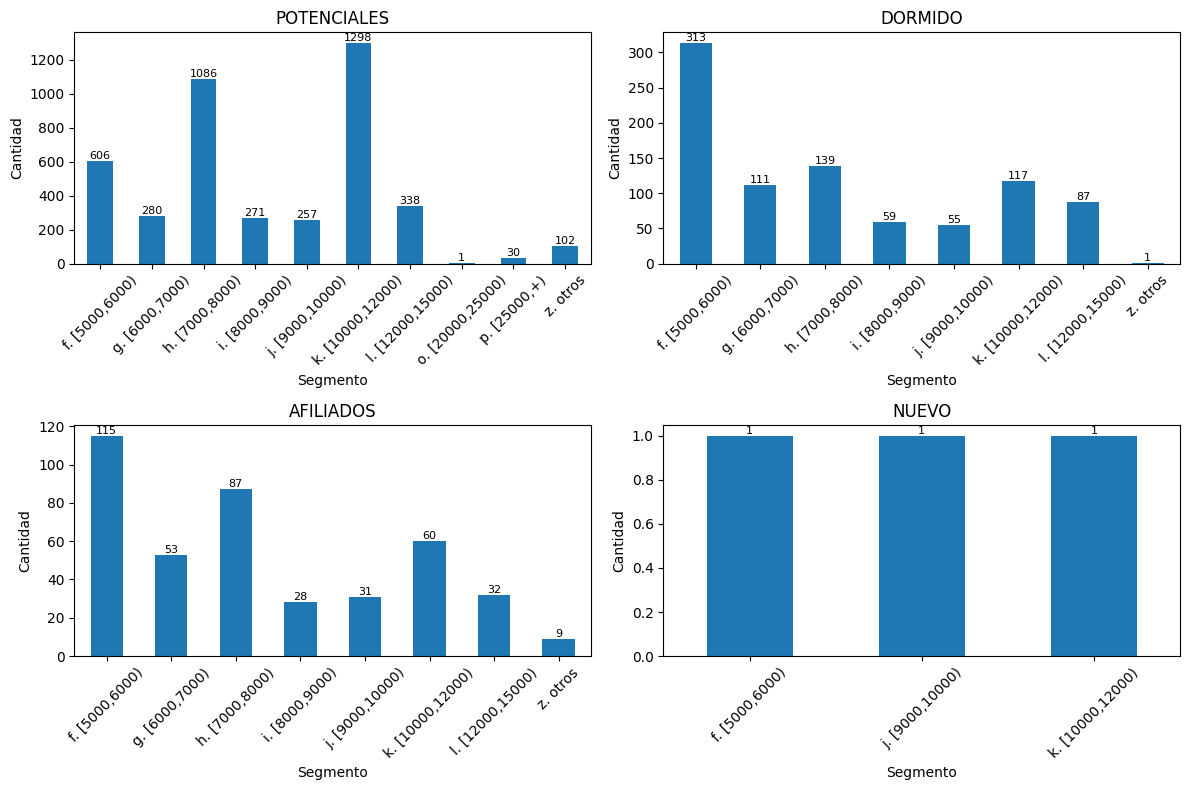

In [24]:
import matplotlib.pyplot as plt
import pandas as pd

top_names = df_dni['first_name'].value_counts().head(4).index
df_filtrado = df_dni[df_dni['first_name'].isin(top_names)]

# Crear subplots (2x2 por ejemplo)
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, name in enumerate(top_names):
    data = df_filtrado[df_filtrado['first_name'] == name]['seg_linea_hs_plus'].value_counts().sort_index()
    
    ax = axes[i]
    data.plot(kind='bar', ax=ax)
    
    ax.set_title(name)
    ax.set_xlabel('Segmento')
    ax.set_ylabel('Cantidad')
    ax.tick_params(axis='x', rotation=45)

    # 👉 etiquetas
    for j, v in enumerate(data):
        if v > 0:
            ax.text(j, v, str(v), ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()


In [112]:
df_dni = df_list.toPandas()


In [20]:

df_filtrado = df_filtrado.select(
    'vendor_lead_code', 'phone_number', 'first_name',
    'last_name', 'address1', 'address3',
    'city', 'province', 'email', 'comments'
).orderBy(F.col('linea_hs_plus').desc())

In [9]:
df_filtrado.filter(col('vendor_lead_code')=='10323568').show()

+----------------+------------+----------+---------+--------+--------+----+--------+-----+--------+
|vendor_lead_code|phone_number|first_name|last_name|address1|address3|city|province|email|comments|
+----------------+------------+----------+---------+--------+--------+----+--------+-----+--------+
+----------------+------------+----------+---------+--------+--------+----+--------+-----+--------+



In [60]:

df_filtrado = df_filtrado.select(
    'vendor_lead_code', 'phone_number', 'first_name',
    'last_name', 'address1', 'address3',
    'city', 'province', 'email', 'comments'
).orderBy(F.col('linea_hs_plus').desc())

df_dni = df_filtrado.toPandas()
import os

ruta_archivo = os.path.join(ruta_csv, 'consumo_202603311255.xlsx')

df_dni.to_excel(ruta_archivo, index=False)

In [4]:
ruta_csv

'C:\\Users\\DATA\\Documents\\datos\\05_subir_csv'

In [16]:
filename2='PLANTILLA_BD_ECR_TARGET_SUBIR - copia.csv'
filename1='PLANTILLA_BD_EC_TARGET_SUBIR - copia.csv'

df_prueba1=cargar_archivo_csv(spark,'C:\\Users\\DATA\\Documents\\datos\\05_subir_csv\\' +filename2,';',True)
df_prueba2=cargar_archivo_csv(spark,'C:\\Users\\DATA\\Documents\\datos\\05_subir_csv\\' +filename1,';',True)
print(df_prueba1.count())
print(df_prueba2.count())


2100
23500


In [18]:
df_prueba2=df_prueba2.filter(col('CODDOC').isNotNull())
df_prueba1=df_prueba1.filter(col('CODDOC').isNotNull())

In [17]:
print(df_prueba1.columns)
print(df_prueba2.columns)

['CANAL', 'PRODUCTO', 'NUM_CTA', 'NUM_CTA_LP', 'TIPDOC', 'CODDOC', 'LINEA_SAE', 'PCT_SAE', 'TEA', 'PROPENSION', 'CLIENTE_DESDE', 'NOMBRE_1', 'NOMBRE_2', 'APELLIDO_PATERNO', 'APELLIDO_MATERNO', 'CELULAR', 'TELF_DOM', 'TELF_OFI', 'DEPARTAMENTO', 'PROVINCIA', 'DISTRITO', 'DIRECCION', 'FEC_NAC', 'EDAD', 'RNG_LINEA_MAX_TC', 'RNG_SUMA_LINEA_TC', 'RNG_SALDO_CONSUMO', 'RNG_EDAD', 'RNG_SALDO_TC', 'RNG_INGRESO', 'RNG_SALDO_TC_ENTRE_INGRESO', 'RNG_LINEA_TC_CENCO', 'RNG_LINEA_TCENCO_ENTRE_LIN_MAX', 'RNG_SALDO_CONSUMO_ENTRE_INGRESO', 'RNG_SALDO_TC_ENTRE_LINEA_TOTAL_TC', 'REGIMEN_LABORAL', 'FEC_FACTURACION', 'FECHA_ULT_COMP', 'FECHA_ULT_AE', 'MONTO_ULT_AE', 'CUOTA_ULT_AE', 'FECHA_ULT_SAE', 'FECHA_ULT_ATM', 'FEC_PAGO', 'CEL01', 'CEL02', 'CEL03', 'CEL04', 'CEL05', 'CEL06', 'CEL07', 'CEL08', 'TELF1', 'TELF2', 'TELF3', 'TELF4', 'TELF5', 'TELF6', 'TELF7', 'TELF8', 'FECHA_ENVIO', 'MES_DURACION_BASE', 'AÑO_DURACION_BASE', 'SERVICIO', 'RETIRO', 'MARCA', 'FLAT1', 'FLAT2', 'FLAT3', 'REP1', 'REP2', 'MONTO_DESE

In [19]:
append_table_SQL(spark,df_prueba1,'Base_Maestra_Cencosud_PPFF',server_kishin,user_kishin,pwd_kishin,'DANTALION')
append_table_SQL(spark,df_prueba2,'Base_Maestra_Cencosud_PPFF',server_kishin,user_kishin,pwd_kishin,'DANTALION')


In [8]:
query=f'''
    select * from cronox.dbo.borrar_df_efe_negocio_01
'''
df_list = obtener_tabla_sql(spark,query,server_sa,user_sa,pwd_sa,db_sa)

In [9]:

df_prueba = df_prueba.withColumn(
    "DNI",
    F.right(F.lpad(F.col("DNI").cast("string"), 8, "0"), F.lit(8))
)
df_prueba = df_prueba.filter(
    (F.col("TELEFONO").rlike(r"^[0-9]+$")) &
    (F.col("TELEFONO").startswith("9")) &
    (F.length(F.col("TELEFONO")) == 9)
)
df_prueba=df_prueba.withColumnRenamed('DNI','vendor_lead_code')
df_prueba=df_prueba.withColumnRenamed('TELEFONO','TELEFONO__1')
df_list=df_list.join(df_prueba,['vendor_lead_code'],'inner')

In [10]:


df_list = df_list.withColumn(
    "phone_number",
    F.col("TELEFONO__1")
).drop("TELEFONO__1")

df_list = df_list.dropDuplicates(
    ["vendor_lead_code", "phone_number"]
)


In [11]:
df_list.count()

3388

In [12]:
df_filtrado = df_list.select(
    'vendor_lead_code', 'phone_number', 'phone_number_02', 'title', 'first_name',
    'last_name', 'address1', 'address2', 'address3',
    'city', 'province', 'email', 'security_phrase', 'comments','mejor15_descripcion_telf'
)
df_dni = df_filtrado.toPandas()

import os
ruta_archivo = os.path.join(ruta_csv, 'carga_0104.xlsx')

df_dni.to_excel(ruta_archivo, index=False)

In [ ]:

df_list=df_list.select('vendor_lead_code', 'phone_number', 'phone_number_02', 'title', 'first_name', 'last_name', 'address1', 'address2', 'address3', 'city', 'province', 'email', 'security_phrase', 'comments')
df_list.count()

In [7]:
df_prueba.show()

+--------+---------+
|     DNI| TELEFONO|
+--------+---------+
|74932885|973453251|
|26690636|976613727|
| 3356503|968055419|
|42277269|990198478|
|19885806|983550028|
|40353032|962071010|
|43656504|962996948|
|42229745|985187648|
|29704979|947499878|
|10594441|991763380|
|20570444|933283306|
|45214063|971113443|
|41592580|940124810|
| 3489851|968222656|
|44654712|967808849|
|70361327|973891910|
|18121613|942855505|
|40502869|990073819|
|46452186|917075087|
|29717319|959333900|
+--------+---------+
only showing top 20 rows


In [8]:
df_prueba.show()

+----------+----------------+--------------------+--------+------------+--------------------+--------+--------------------+
|     FECHA|vendor_lead_code|             CLIENTE|   MONTO|phone_number|               PLAZA|PROMOTOR|              ASESOR|
+----------+----------------+--------------------+--------+------------+--------------------+--------+--------------------+
|03/03/2026|        09204144|ESPINOZA TORREJON...| 4515.00|   998995111|           TARMA EFE|  PEC155|ALEXIS MARCELO JA...|
|03/03/2026|        47611036|RAICO PEREZ MARIA...| 4059.00|   980521115|       CAJAMARCA EFE|  PEC155|ALEXIS MARCELO JA...|
|03/03/2026|        44733555|VILLALOBOS TORRES...| 7015.00|   925546151|     JUANJUI TSE  LC|  PEC155|ALEXIS MARCELO JA...|
|03/03/2026|        08332431|VALENCIA CALVO LU...| 8305.00|   987603779|         CACERES EFE|  PEC155|ALEXIS MARCELO JA...|
|04/03/2026|        26953125|LOPEZ INGA LADISL...| 3759.00|   947017529|JR  CELSO BENIGNO...|  PEC155|ALEXIS MARCELO JA...|
|04/03/2

In [6]:
df_prueba=df_prueba.withColumnRenamed('DNI TRUE','vendor_lead_code')
df_prueba=df_prueba.withColumnRenamed('TELEFONO','phone_number')

In [ ]:
df_prueba=df_prueba.withColumnRenamed('DNI TRUE','vendor_lead_code')
df_prueba=df_prueba.withColumnRenamed('TELEFONO','phone_number')

df_prueba = df_prueba.withColumn(
    "vendor_lead_code",
    F.right(
        F.concat(F.lit("00000000"), F.col("vendor_lead_code")),
        F.lit(8)
    )
)
df_prueba = df_prueba.filter(
    F.col("phone_number").rlike(r"^9\d{0,8}$")
)

In [ ]:

df_list=df_list.drop('phone_number')

In [ ]:

df_list=df_list.join(df_prueba,['vendor_lead_code'],'inner')

print(df_list.count())

7930


In [14]:

df_list = df_list.select(
    'vendor_lead_code', 'phone_number', 'first_name',
    'last_name', 'address1', 'address3',
    'city', 'province', 'email', 'comments'
).orderBy(F.col('linea_hs_plus').desc())

df_dni = df_list.toPandas()
import os

ruta_archivo = os.path.join(ruta_csv, 'BASE_SEGUIMIENTO_REINGRESO_20260330.xlsx')

df_dni.to_excel(ruta_archivo, index=False)

In [15]:
df_dni.count()

vendor_lead_code    7930
phone_number        7930
first_name          7930
last_name           7930
address1            7930
address3            1238
city                7930
province            7930
email               7924
comments            7930
dtype: int64

# historico prioridad

In [ ]:
fecha_mes_base='2026-04-01'
query = f"""
SELECT 
vendor_lead_code,
prioridad_hist
FROM (
    SELECT 
        RIGHT(REPLICATE('0',8) + CAST(a.NUMERO_DOCUMENTO AS VARCHAR(20)), 8) as vendor_lead_code,
        b.GRUPO_EJECUCION as prioridad_hist,
        TRY_CONVERT(date, b.fecha_envio) as fecha_envio,
        ROW_NUMBER() OVER (
            PARTITION BY a.NUMERO_DOCUMENTO 
            ORDER BY TRY_CONVERT(date, b.fecha_envio) DESC
        ) as rn
    FROM DANTALION.dbo.Base_Maestra_Diners_TC_Vigente a
    INNER JOIN DANTALION.dbo.Base_Maestra_Diners_TC b
        ON a.NUMERO_DOCUMENTO = b.NUMERO_DOCUMENTO
    WHERE b.GRUPO_EJECUCION IS NOT NULL
    AND b.NUMERO_DOCUMENTO IS NOT NULL
    AND TRY_CONVERT(date, b.fecha_envio) IS NOT NULL
    AND TRY_CONVERT(date, b.fecha_envio) >= DATEADD(MONTH, -6, '{fecha_mes_base}')
    AND TRY_CONVERT(date, b.fecha_envio) <'{fecha_mes_base}'
) t
WHERE rn = 1
"""
df_hist=obtener_tabla_sql(spark,query,server_kishin,user_kishin,pwd_kishin,db_kishin)

print(df_hist.columns)

['vendor_lead_code', 'prioridad_hist']


In [103]:
overwrite_table_SQL(spark,df_hist,'borrar_tc_dinner_prioridad_hist',server_sa,user_sa,pwd_sa,'CRONOX')


## inventario

In [ ]:
list_tipi=['MALA EXPERIENCIA', 'CLIENTE ACEPTO OFERTA TC + ADICIONAL (SEGURO)', 'POR SEGURO DE DESGRAVAMEN ', 'POR LINEA DE CREDITO', 'TASA DE INTERES ALTA', 'VENTA POR OTRO CANAL', 'CLIENTE SE ACERCARÁ A DC', 'CLIENTE ACEPTO OFERTA TC SIN TRANSFERIR', 'AGENDA', 'CLIENTE NO ESCUCHA OFERTA', 'POR MEMBRESÍA', 'CLIENTE CORTO DESPUES DE ESCUCHAR OFERTA', 'CLIENTE ACEPTO OFERTA TC (SEGURO)', 'ACEPTA ENVIO WHATSAPP', 'CLIENTE ACEPTO OFERTA TC + ADICIONAL  SIN TRANSFERIR', 'PROGRAMA DE RECOMPENSAS', 'NO RECONOCE LA MARCA', 'CLIENTE CORTO SIN ESCUCHAR OFERTA', 'NO CONFIA EN VENTA TELEFONICA', 'SE ENCUENTRA DE VIAJE', 'CLIENTE NO ESCUCHA OFERTA - TITULAR OCUPADO', 'CLIENTE NO ESCUCHA OFERTA - ACEPTA WHATSAPP', 'PREFIERE SU PROPIO BANCO', 'TITULAR DESEA QUE VUELVAN A LLAMAR', 'NO DESEA DAR MOTIVOS']
fecha_mes_base = '2026-04-01'
tipi_estado='[NIVEL 2]'
lla_nombre_campana='DINERS TC'
tipi_descrip='[NIVEL 4]'
tb_tipologia='tTipologia_Diners_TC'
dni_tnumero='NUMERO_DOCUMENTO'
cod_letra='H'
tb_tnumero='tNumeroDinersTc'
tipi_cod='cod'


query = f"""
SELECT dni as vendor_lead_code,
phone_number,
codigo_paleta,
    DATEDIFF(MONTH, fecha_llamada, '{fecha_mes_base}') AS n_mes
FROM SAMANTHa.dbo.tmp_llamadas_mes 
WHERE dni is not null 
and nombre_campana LIKE '%{lla_nombre_campana}'
AND fecha_llamada >= DATEADD(MONTH, -6, '{fecha_mes_base}')
AND fecha_llamada <  '{fecha_mes_base}'
"""
df_llamadas=obtener_tabla_sql(spark,query,server_zeus,user_zeus,pwd_zeus,db_zeus)

query = f"""
select {tipi_cod} as codigo_paleta,peso,{tipi_descrip} as descripcion from ODIN.dbo.{tb_tipologia}
where {tipi_estado}='CONTACTO EFECTIVO'
and LEFT({tipi_cod},1)='{cod_letra}'
"""
df_tipi = obtener_tabla_sql(spark,query,server_zeus,user_zeus,pwd_zeus,db_zeus)
df_tipi=df_tipi.filter(col('descripcion').isin(list_tipi))
df_llamadas=df_llamadas.join(df_tipi,['codigo_paleta'],'inner')

window_spec = Window.partitionBy("vendor_lead_code", "phone_number") \
    .orderBy(
        F.col("n_mes").asc_nulls_last(),
        F.col("peso").desc_nulls_last()
    )

df_llamadas = df_llamadas.withColumn("ref_01", row_number().over(window_spec))
df_llamadas = df_llamadas.filter(F.col("ref_01") == 1).drop('ref_01')

query = f"""
select distinct {dni_tnumero} as vendor_lead_code,Telefonos as phone_number 
from DANTALION.dbo.{tb_tnumero}
"""
df_tnumero=obtener_tabla_sql(spark,query,server_kishin,user_kishin,pwd_kishin,db_kishin)
df_tnumero=df_tnumero.join(df_llamadas,['vendor_lead_code', 'phone_number'],'inner')
overwrite_table_SQL(spark,df_tnumero,'borrar_tc_dinner_cet',server_sa,user_sa,pwd_sa,'CRONOX')

In [ ]:

print([row['descripcion' ] for row in df_tipi.select('descripcion').distinct().collect()])


['MALA EXPERIENCIA', 'CLIENTE ACEPTO OFERTA TC + ADICIONAL (SEGURO)', 'POR SEGURO DE DESGRAVAMEN ', 'POR LINEA DE CREDITO', 'TASA DE INTERES ALTA', 'VENTA POR OTRO CANAL', 'CLIENTE SE ACERCARÁ A DC', 'DESEA EFECTIVO  - TIENE UN PRESTAMO', 'NO TIENE ACEPTACION', 'CLIENTE ACEPTO OFERTA TC SIN TRANSFERIR', 'AGENDA', 'CLIENTE NO ESCUCHA OFERTA', 'POR MEMBRESÍA', 'NO CALIFICA ENTREGA', 'CLIENTE CORTO DESPUES DE ESCUCHAR OFERTA', 'CLIENTE ACEPTO OFERTA TC (SEGURO)', 'CLIENTE DESEA QUE NO VUELVAN A LLAMAR', 'ACEPTA ENVIO WHATSAPP', 'CLIENTE ACEPTO OFERTA TC + ADICIONAL  SIN TRANSFERIR', 'NO CALIFICA COMERCIAL', 'PROGRAMA DE RECOMPENSAS', 'NO RECONOCE LA MARCA', 'CLIENTE CORTO SIN ESCUCHAR OFERTA', 'NO CONFIA EN VENTA TELEFONICA', 'SE ENCUENTRA DE VIAJE', 'CLIENTE NO ESCUCHA OFERTA - TITULAR OCUPADO', 'CLIENTE NO ESCUCHA OFERTA - ACEPTA WHATSAPP', 'PREFIERE SU PROPIO BANCO', 'TITULAR DESEA QUE VUELVAN A LLAMAR', 'NO DESEA DAR MOTIVOS']


In [ ]:
df_tnumero=df_tnumero.withColumn('n_lista',when(((col('descripcion')=='SI QUIERE')|(col('descripcion')=='CREDITO CONCRETADO'))&(col('n_mes')==1),1)
                                            .when((col('descripcion').isin(tipis))&(col('n_mes')>1),3)
                                            .when((col('descripcion').isin(tipis))&(col('n_mes')==1),4)
                                            .when((col('descripcion').isin(tipis))&(col('n_mes')==1),4)
                                            .otherwise(0))


In [3]:

filename='TARGET_202604_01.csv'

df_prueba=cargar_archivo_csv(spark,filename,';',True)
print(df_prueba.columns)

['ID PROVEEDOR', 'NOMBRES', 'APELLIDO PATERNO', 'APELLIDO MATERNO', 'TIPO DE DOCUMENTO', 'NUMERO_DOCUMENTO', 'TASA(TEA)', 'TEA_DF', 'TELEFONO_CASA1', 'TELEFONO_CASA2', 'TELEFONO_CASA3', 'TELEFONO_CASA4', 'TELEFONO_CASA5', 'TELEFONO_CASA6', 'TELEFONO_CASA7', 'TELEFONO_CASA8', 'TELEFONO_CASA9', 'TELEFONO_CASA10', 'NUEVO_GRUPO03', 'PROB_CONTACTO', 'DINERS_NRO1', 'DINERS_NRO2', 'DINERS_NRO3', 'DINERS_NRO4', 'DINERS_NRO5', 'OSIPTEL_NRO1_ENCRIP', 'OSIPTEL_NRO2_ENCRIP', 'OSIPTEL_NRO3_ENCRIP', 'OSIPTEL_NRO4_ENCRIP', 'OSIPTEL_NRO5_ENCRIP', 'DCP01', 'DCP02', 'DCP03', 'DCP04', 'DCP05', 'CELULAR01', 'CELULAR02', 'CELULAR03', 'CELULAR04', 'CELULAR05', 'CELULAR06', 'CELULAR07', 'CELULAR08', 'CELULAR09', 'CELULAR10', 'RECENCIA', 'PERFIL', 'PRODUCTO', 'LINEA_DIN', 'ID RESULTADO GESTION', 'TCEA_NEW', 'TCEA_CUOTAS_DF', 'LIMACALLAO', 'FECHA_NACIMIENTO', 'PROVINCIA', 'L_BCP', 'L_BBVA', 'L_IBK', 'L_SCO', 'L_BIF', 'L_CITI', 'L_FIN', 'L_RIP', 'L_CMR', 'L_CRESCO', 'L_CEN', 'L_AZT', 'L_UNO', 'L_GNB', 'L_EFE', 

In [4]:
df_prueba=df_prueba.select('NUMERO_DOCUMENTO','FUENTE')

df_prueba = df_prueba.withColumn(
    "NUMERO_DOCUMENTO",
    F.right(
        F.concat(F.lit("00000000"), F.col("NUMERO_DOCUMENTO")),
        F.lit(8)
    )
)

In [ ]:
# overwrite_table_SQL(spark,df_prueba,'dinner_borrar_actualizar',server_sa,user_sa,pwd_sa,'CRONOX')
# overwrite_table_SQL(spark,df_prueba,'dinner_borrar_actualizar',server_zeus,user_zeus,pwd_zeus,'ODIN')
# overwrite_table_SQL(spark,df_prueba,'dinner_borrar_actualizar',server_kishin,user_kishin,pwd_kishin,'DANTALION')


In [6]:
df_prueba.columns

['NUMERO_DOCUMENTO', 'FUENTE']

In [ ]:



# df_dni.to_excel(ruta_archivo, index=False)

filename='subir_ventas_dinner_sql.csv'

df_prueba=cargar_archivo_csv(spark,filename,';',True)

df_prueba = df_prueba.withColumn(
    "numero_documento",
    F.right(
        F.concat(F.lit("00000000"), F.col("Número de documento")),
        F.lit(8)
    )
)